In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: For plots
sns.set(style='whitegrid')
%matplotlib inline


In [ ]:
# Step 2: Loading the dataset
df = pd.read_excel("/content/online_course_recommendation_v2.xlsx")
df.head()


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [ ]:
# Step 3: Basic overview
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

Shape of dataset: (100000, 14)

Column names:
 Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken'],
      dtype='object')


In [ ]:
# Step 4: Data Types and Info
df.info()

# Step 5: Summary statistics
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
count,100000.000000,100000.000000,100000,100000,100000.00000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000
unique,NaN,NaN,20,20,NaN,2,3,NaN,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,Networking and System Administration,Jessica Martinez,NaN,Yes,Beginner,NaN,NaN,NaN,NaN,Yes,NaN,NaN
freq,NaN,NaN,5107,5092,NaN,70059,49877,NaN,NaN,NaN,NaN,85147,NaN,NaN
mean,24935.663570,5006.863560,NaN,NaN,52.38354,NaN,NaN,3.959859,25052.822850,261.073369,0.746865,NaN,20.691054,4.992670
std,14406.960108,2882.085456,NaN,NaN,27.42347,NaN,NaN,0.729958,14388.188356,139.013758,0.143683,NaN,13.669148,2.237259
min,1.000000,1.000000,NaN,NaN,5.00000,NaN,NaN,1.000000,50.000000,20.000000,0.092000,NaN,1.000000,0.000000
25%,12487.750000,2523.000000,NaN,NaN,28.60000,NaN,NaN,3.500000,12583.750000,140.100000,0.649000,NaN,9.900000,3.000000
50%,24793.500000,5012.000000,NaN,NaN,52.40000,NaN,NaN,4.000000,25057.500000,262.310000,0.750000,NaN,19.920000,5.000000
75%,37382.250000,7502.000000,NaN,NaN,76.10000,NaN,NaN,4.500000,37522.000000,381.702500,0.851000,NaN,30.080000,6.000000


In [ ]:
# Step 7: Check for duplicate rows
print("Total duplicate rows:", df.duplicated().sum())


Total duplicate rows: 0


In [ ]:
# Step 8: Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", numeric_cols)


Numeric columns: ['user_id', 'course_id', 'course_duration_hours', 'rating', 'enrollment_numbers', 'course_price', 'feedback_score', 'time_spent_hours', 'previous_courses_taken']


In [ ]:

print("Categorical columns:", categorical_cols)


Categorical columns: ['course_name', 'instructor', 'certification_offered', 'difficulty_level', 'study_material_available']


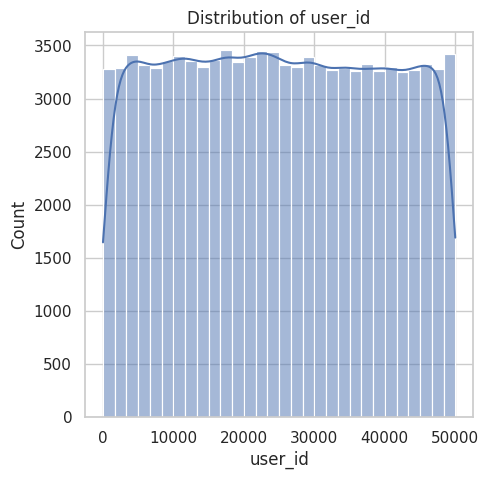

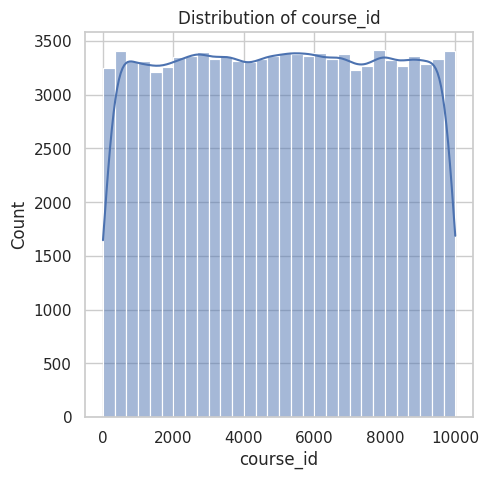

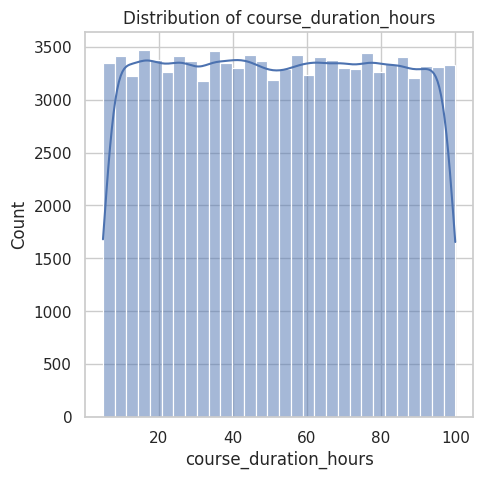

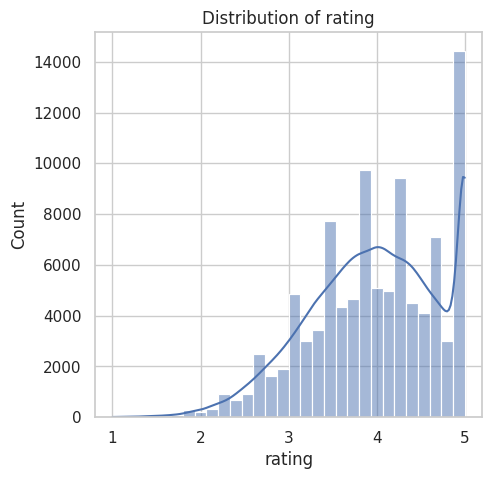

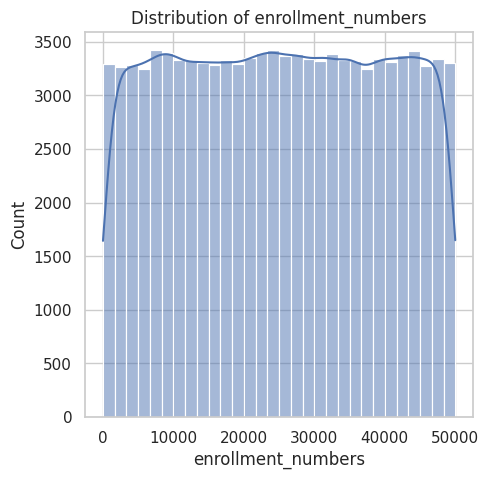

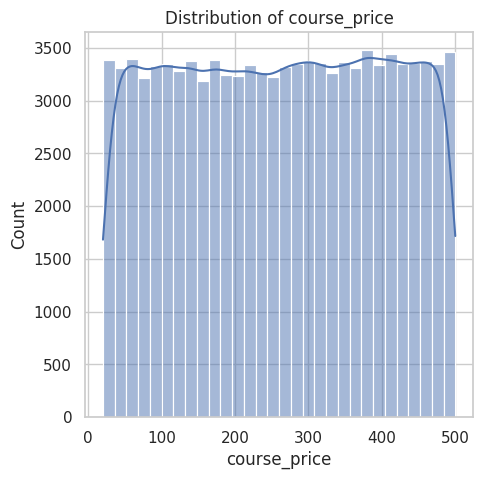

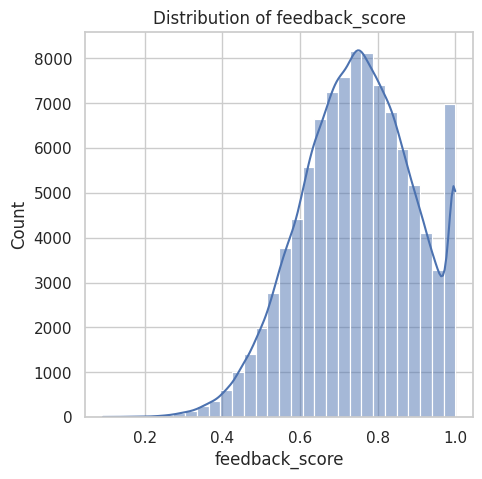

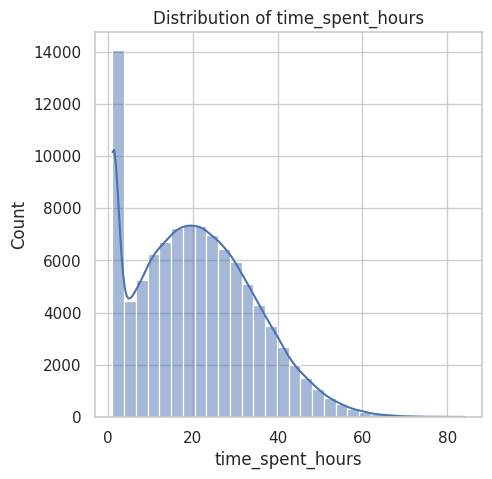

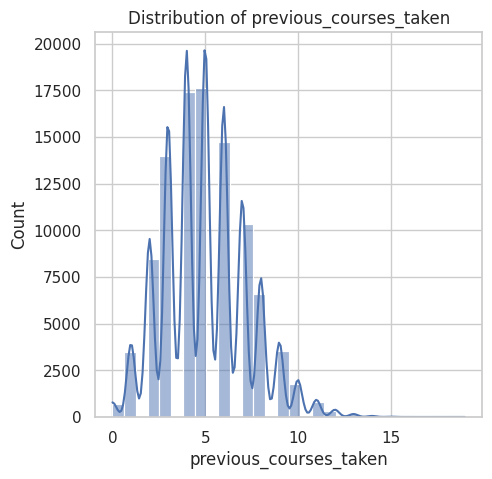

In [ ]:
# Step 9: Univariate Analysis (Numeric Columns)
for col in numeric_cols:
    plt.figure(figsize=(5, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


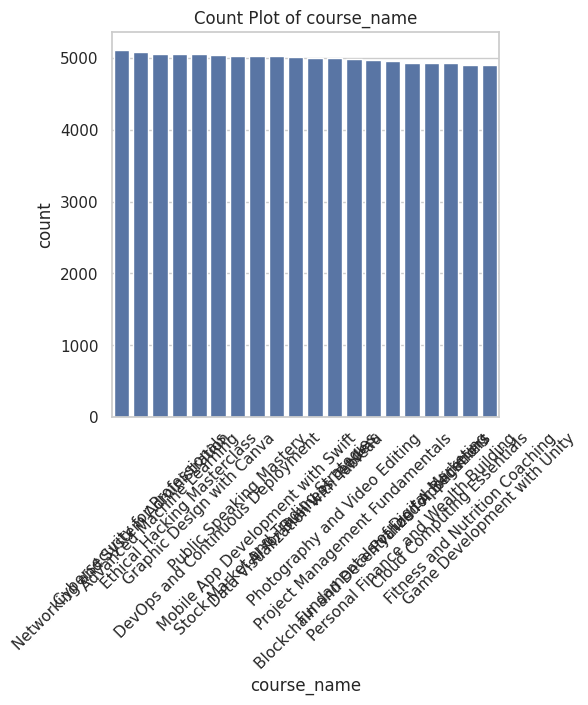

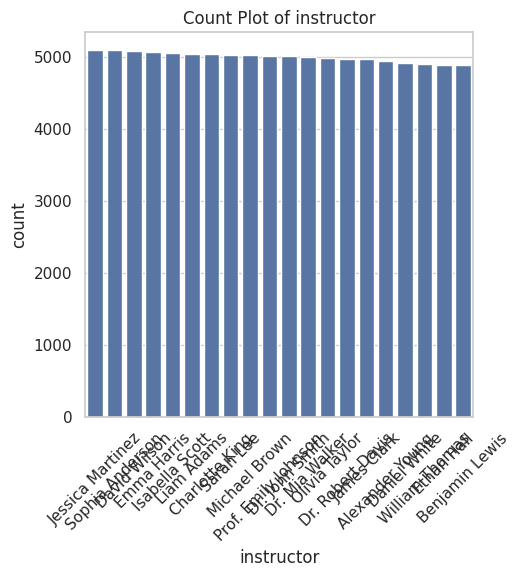

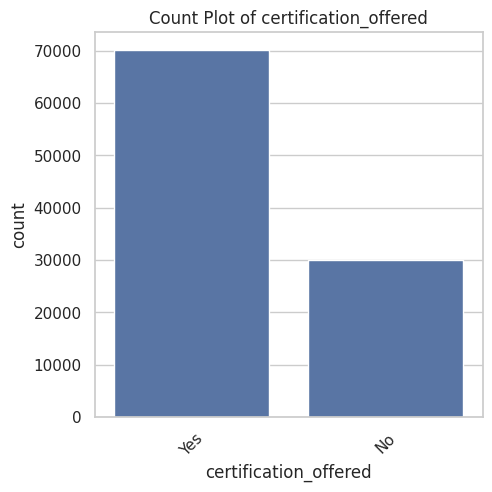

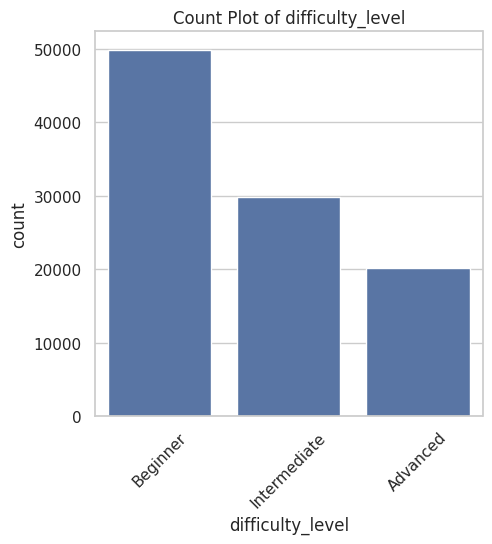

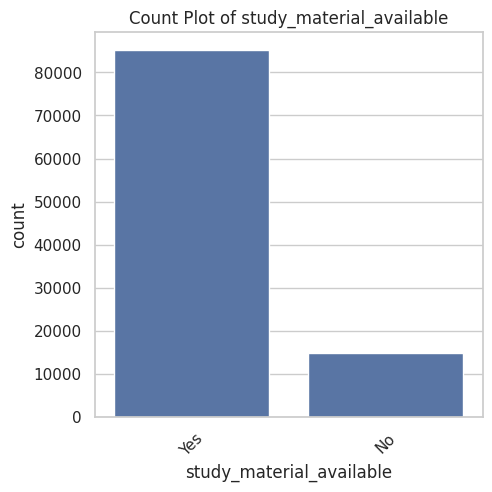

In [ ]:
# Step 10: Univariate Analysis (Categorical Columns)
for col in categorical_cols:
    plt.figure(figsize=(5, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()


# HEAT MAPS

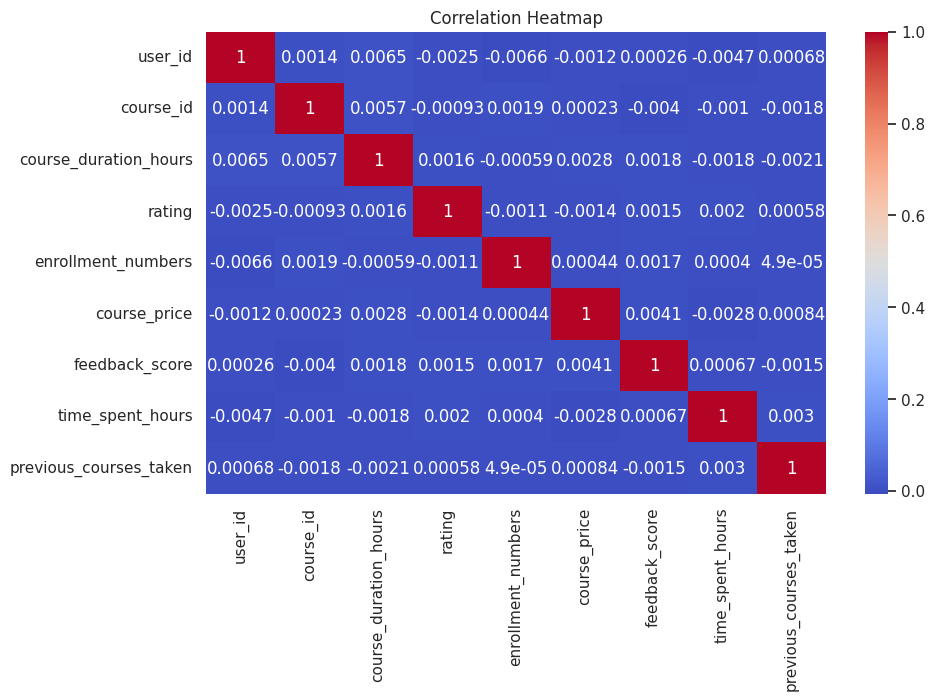

In [ ]:
# Step 11: Correlation Heatmap (only numeric)
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# OUTLIER DETECTION USING BOX PLOTS

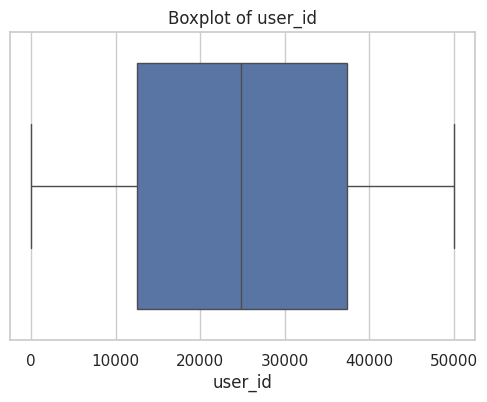

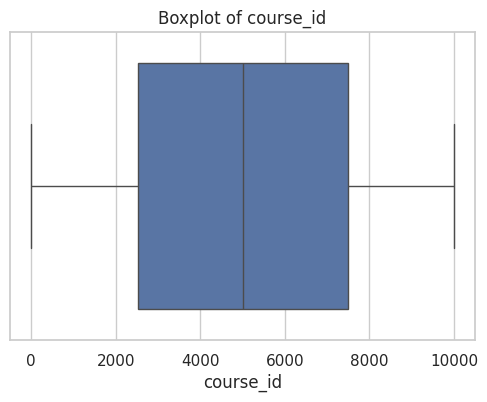

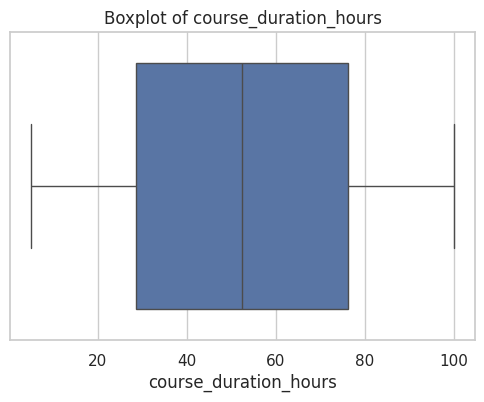

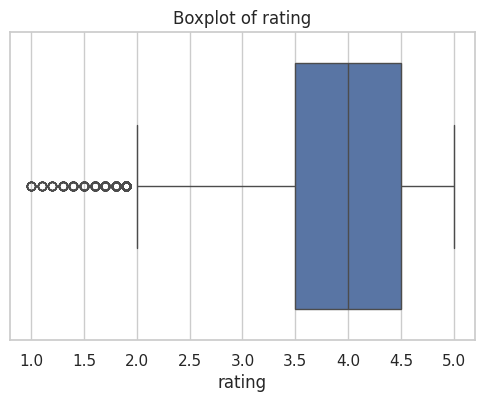

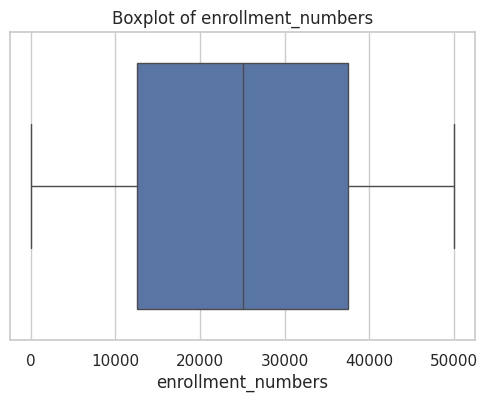

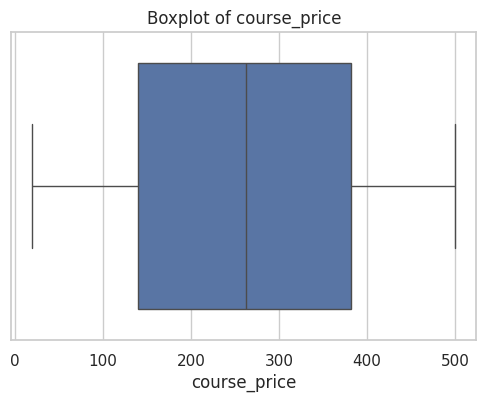

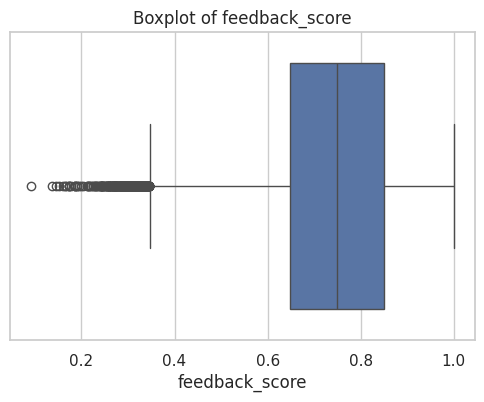

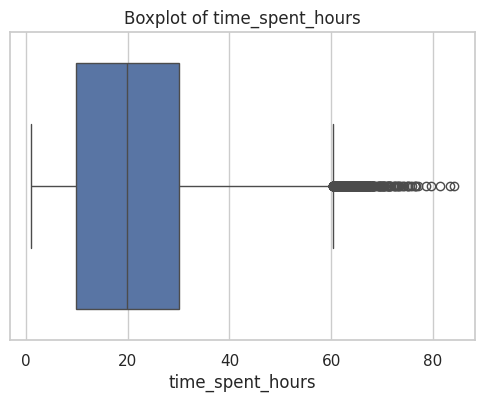

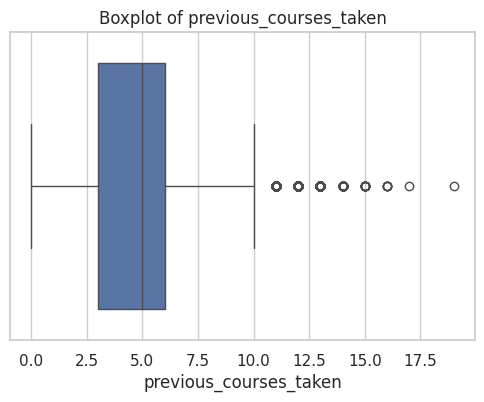

In [ ]:
# Step 12: Boxplots to detect outliers (numeric)
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


# Categorical Vs Numerical Box Plots

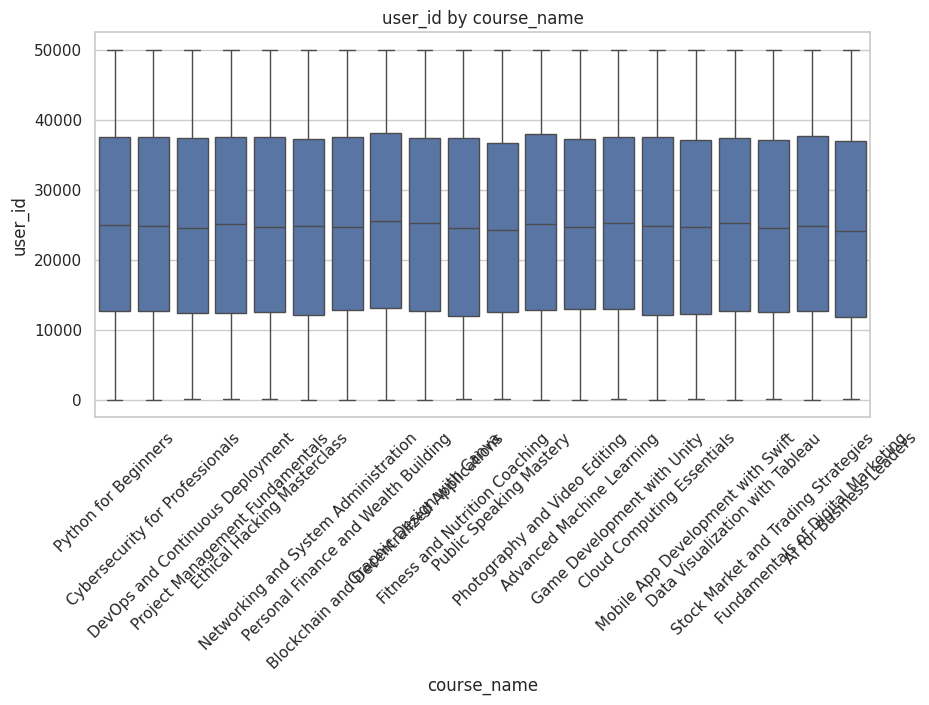

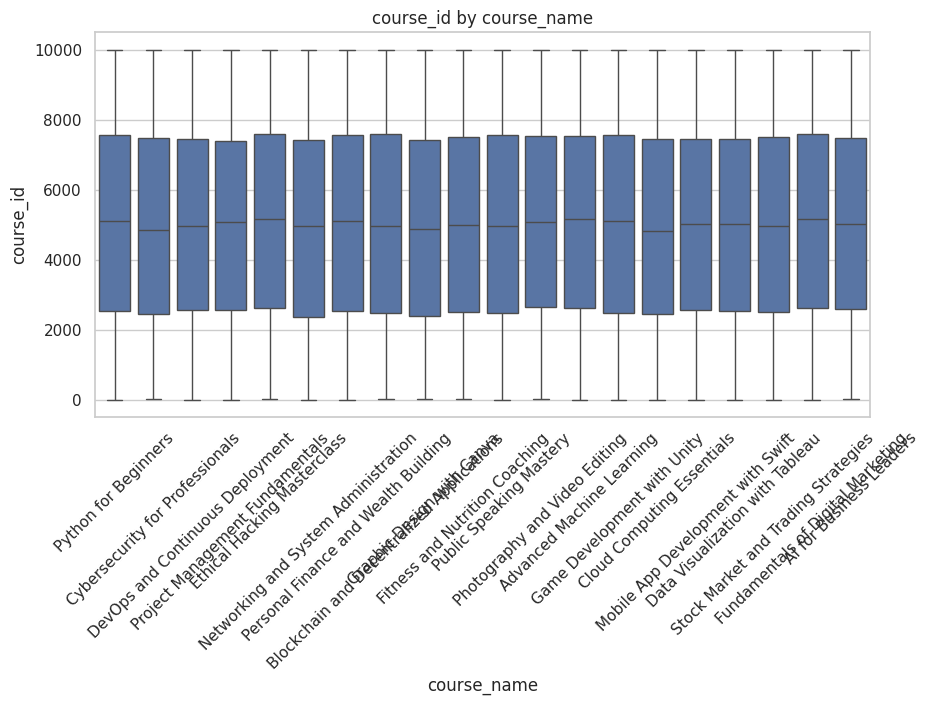

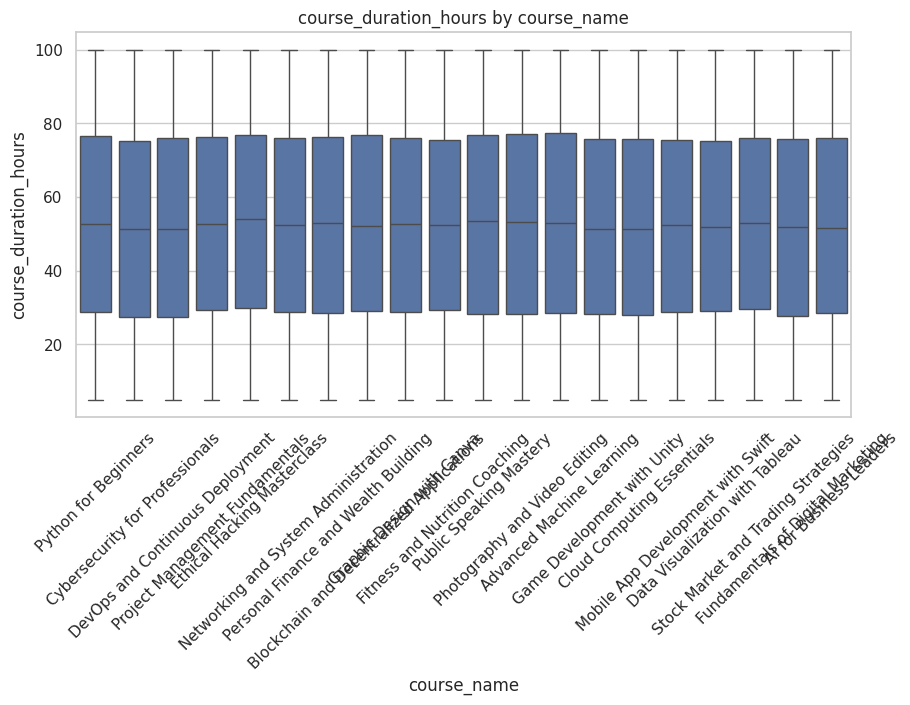

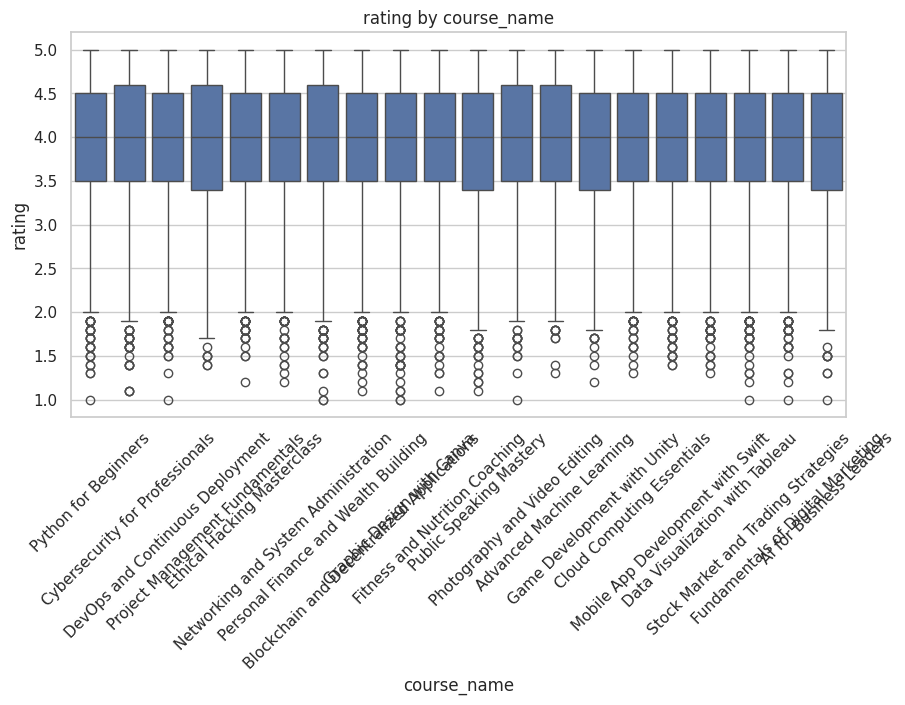

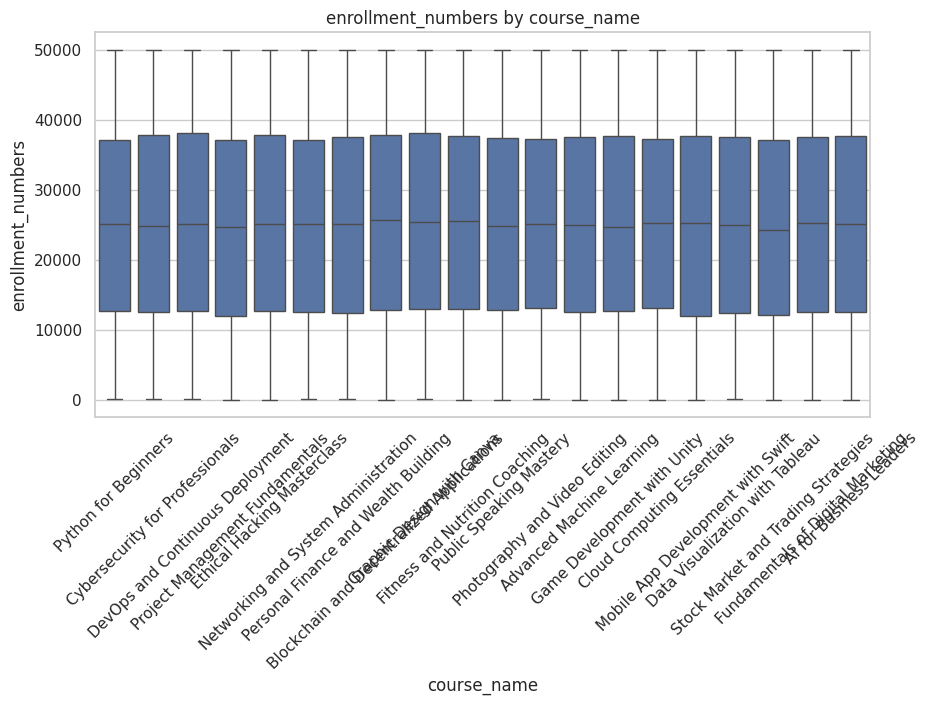

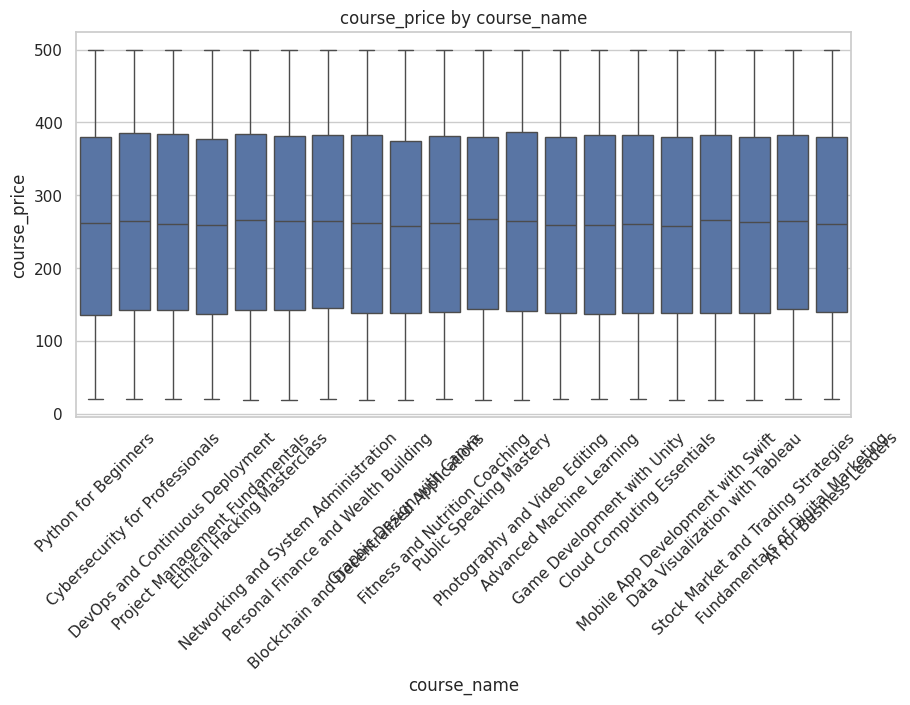

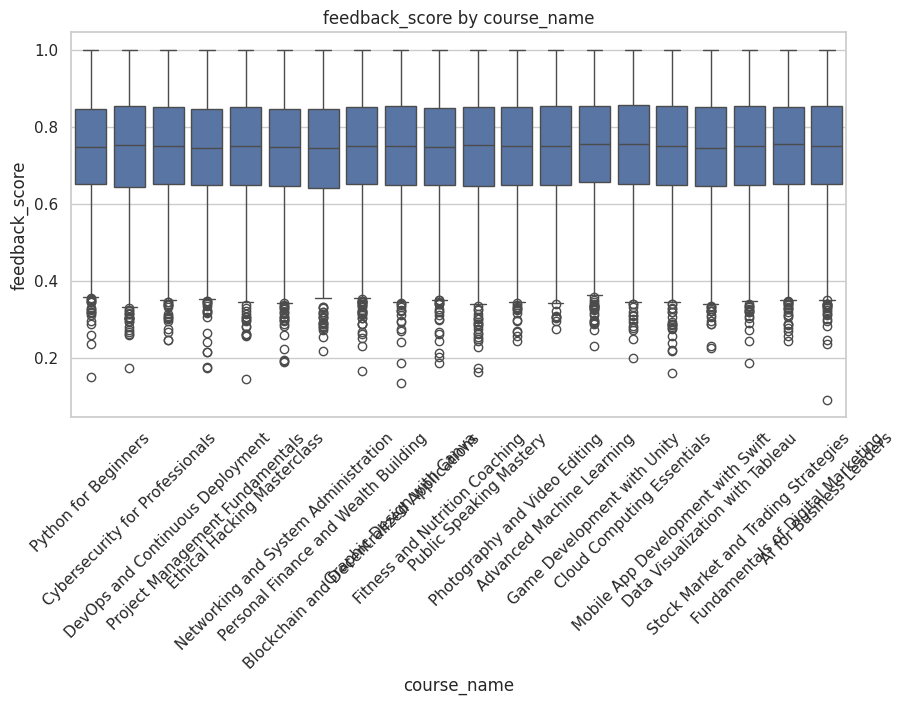

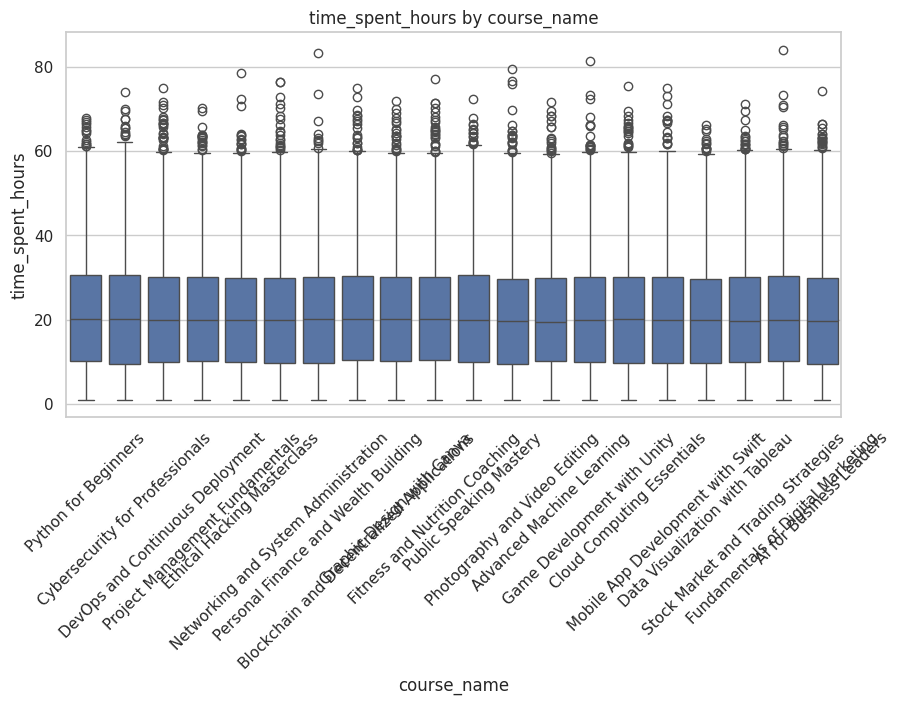

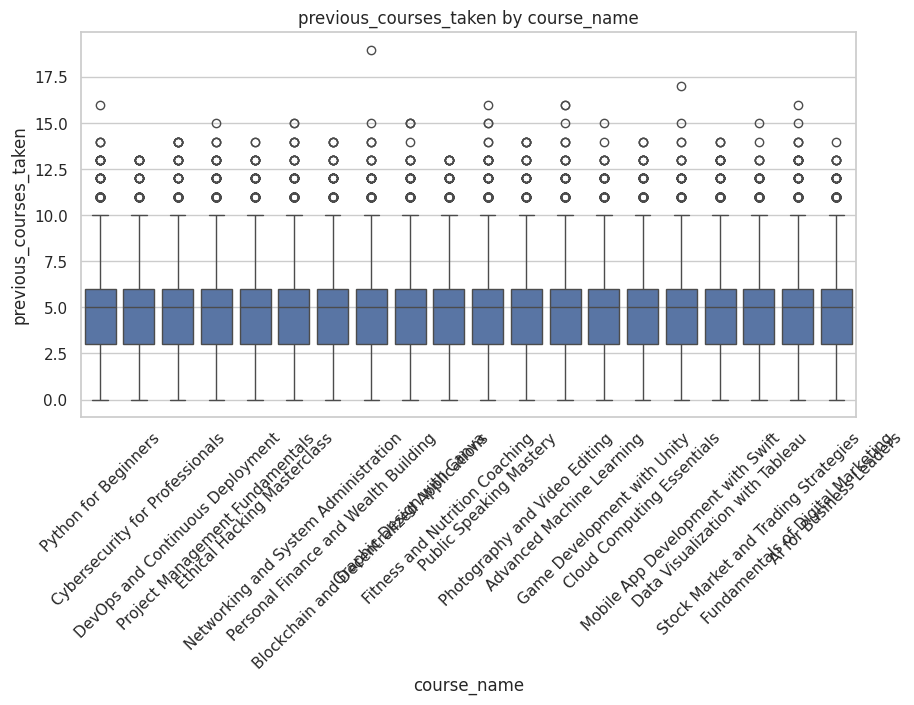

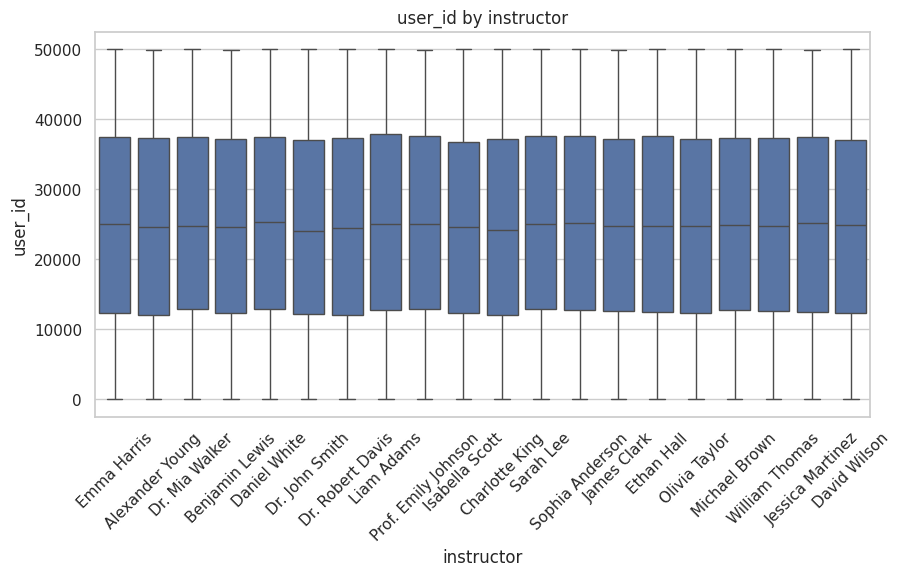

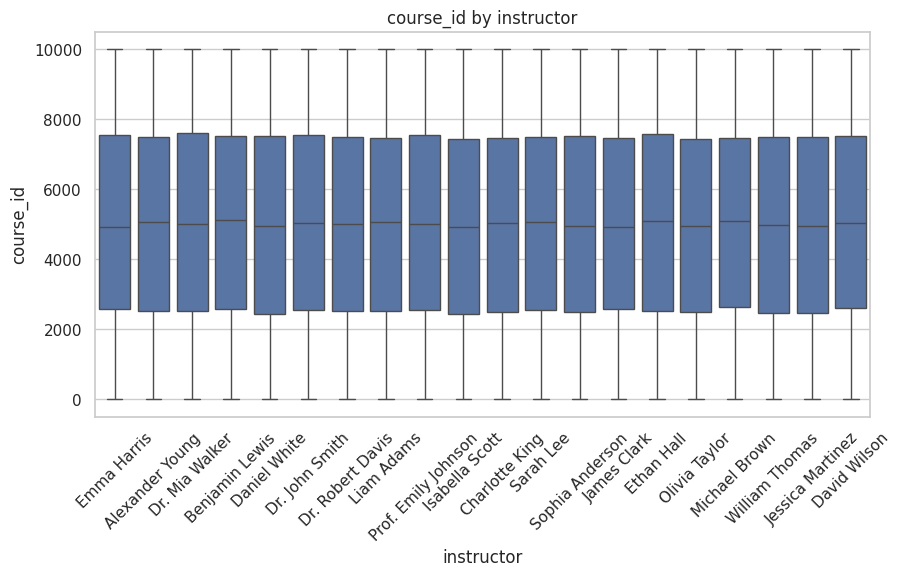

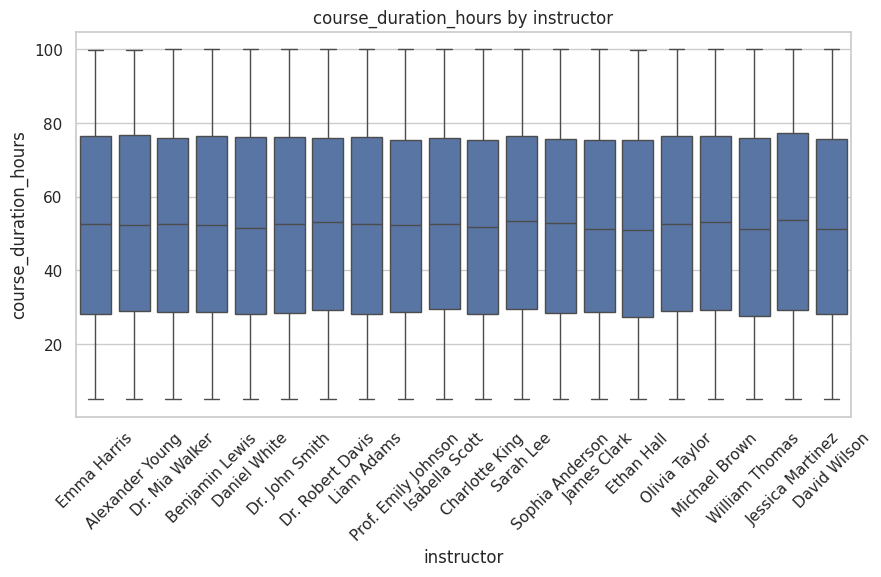

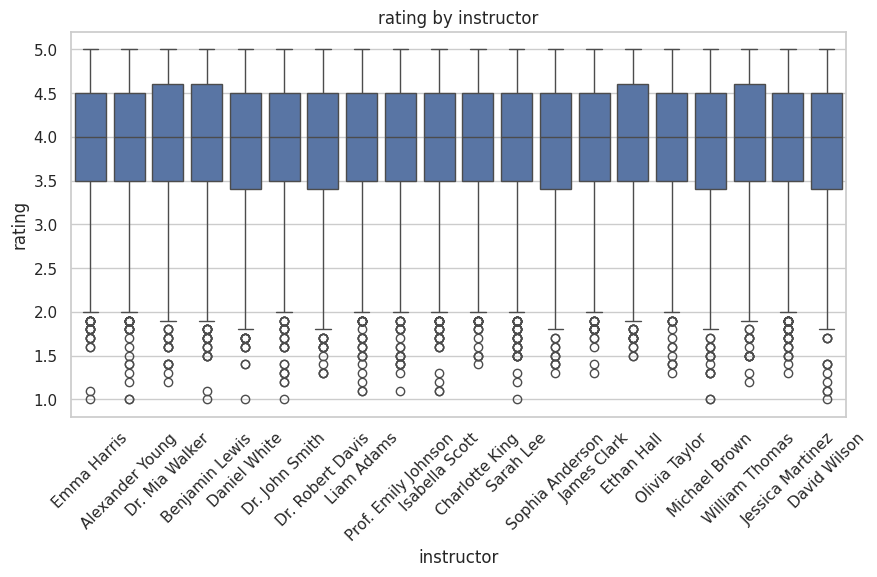

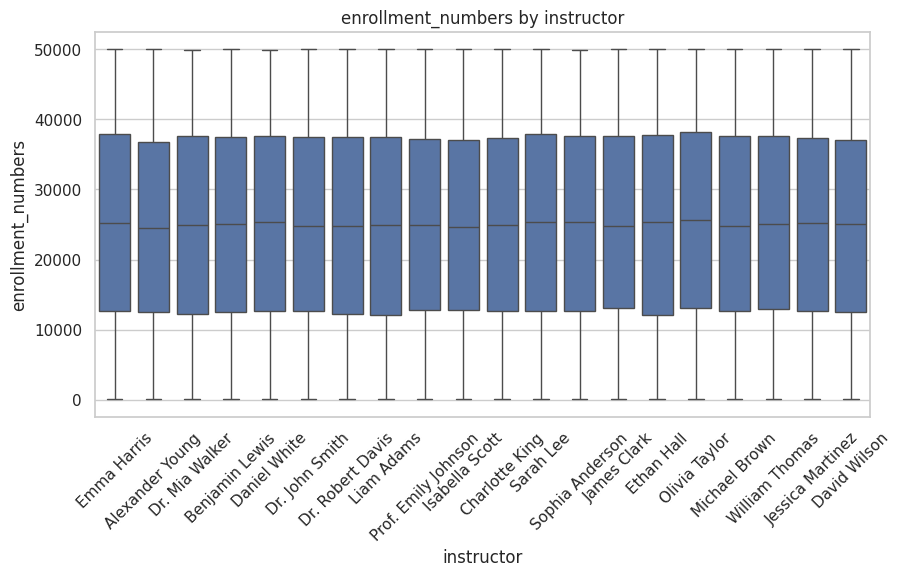

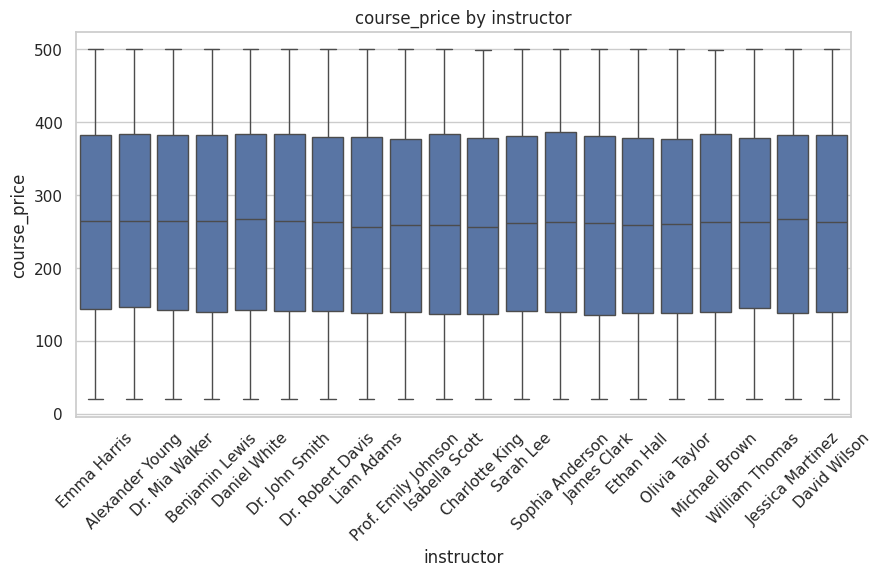

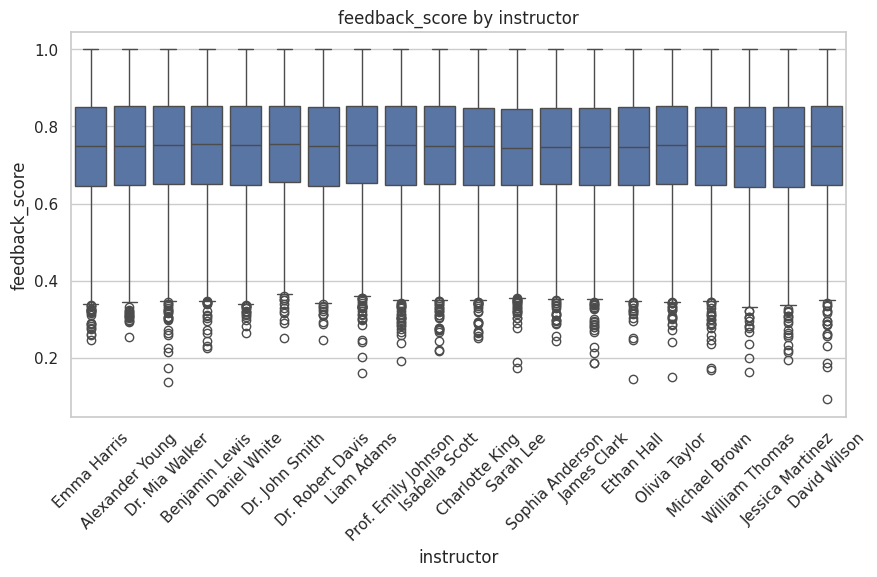

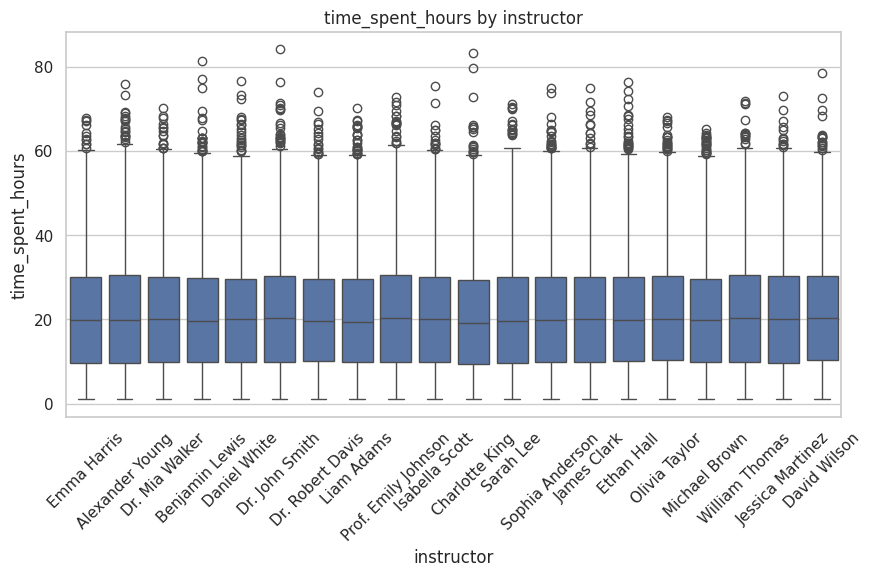

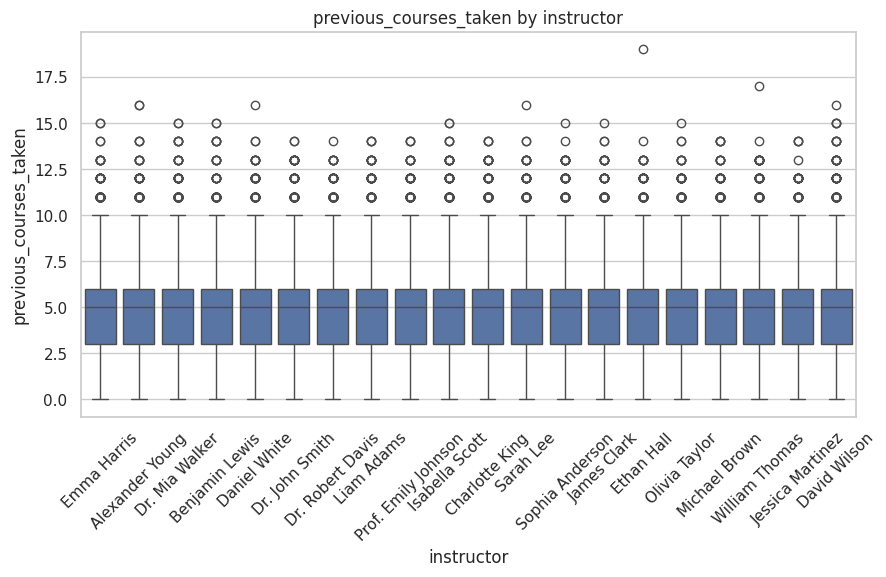

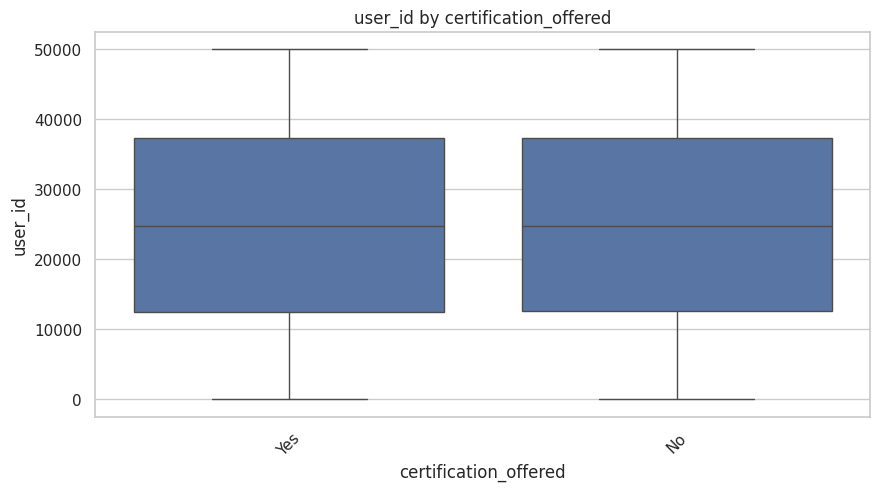

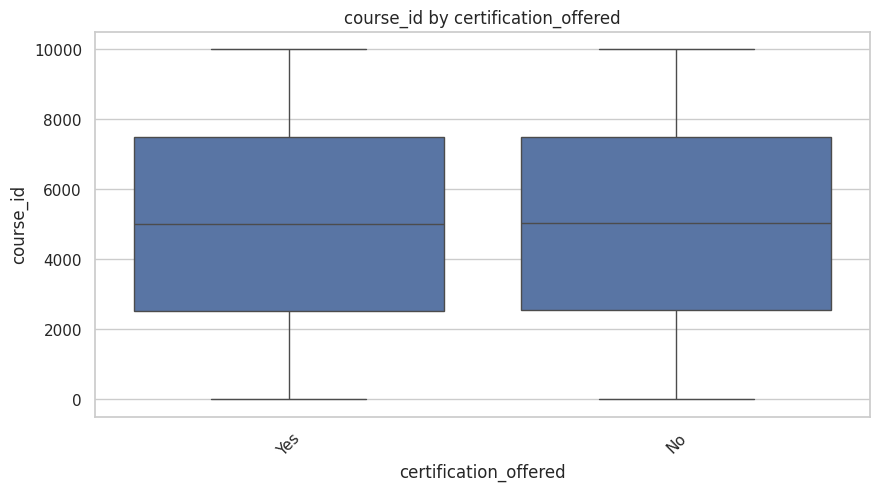

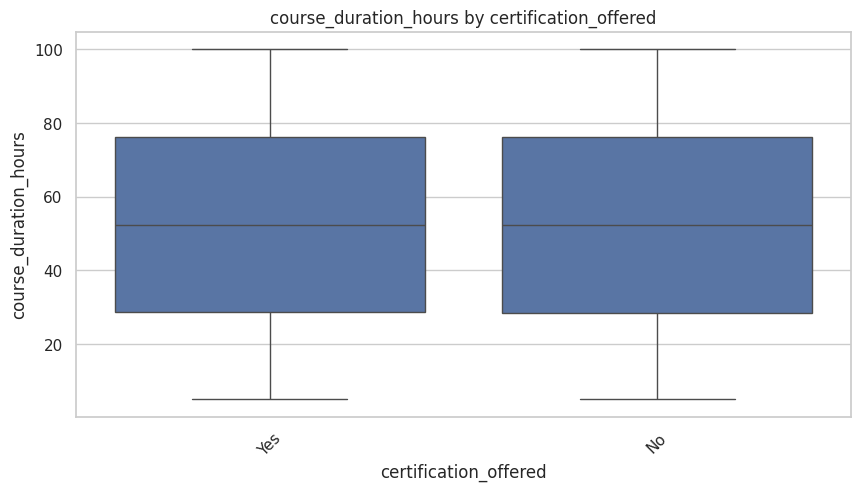

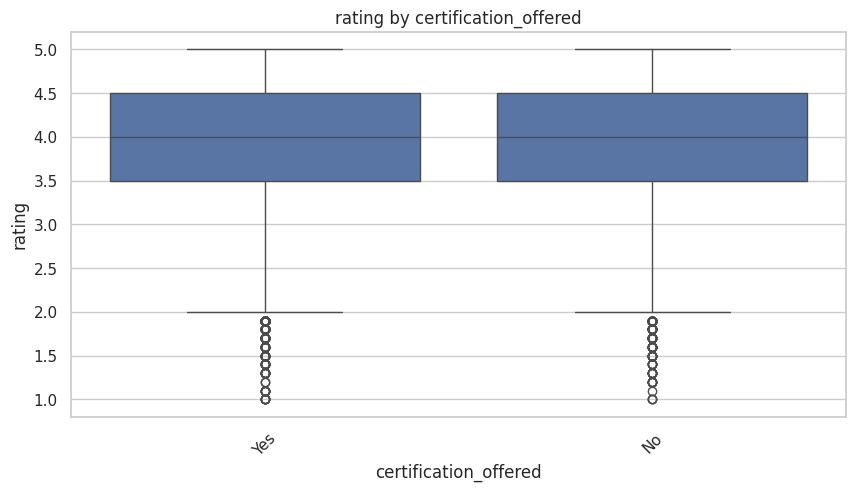

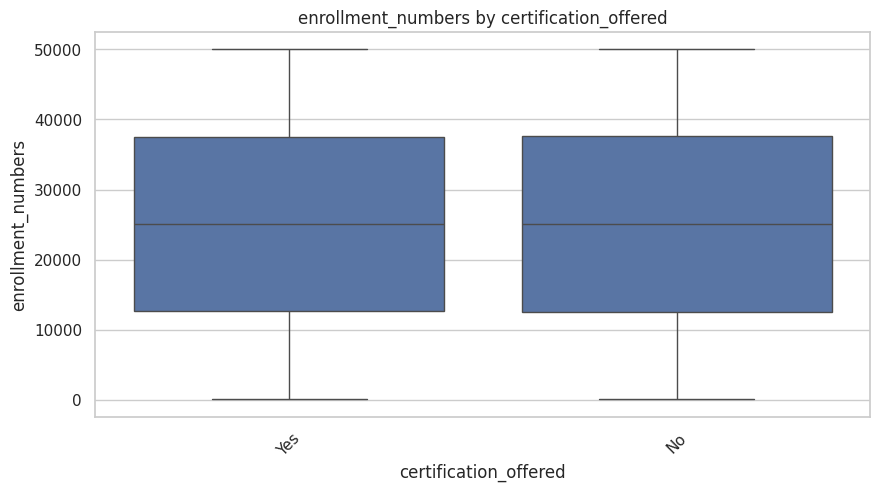

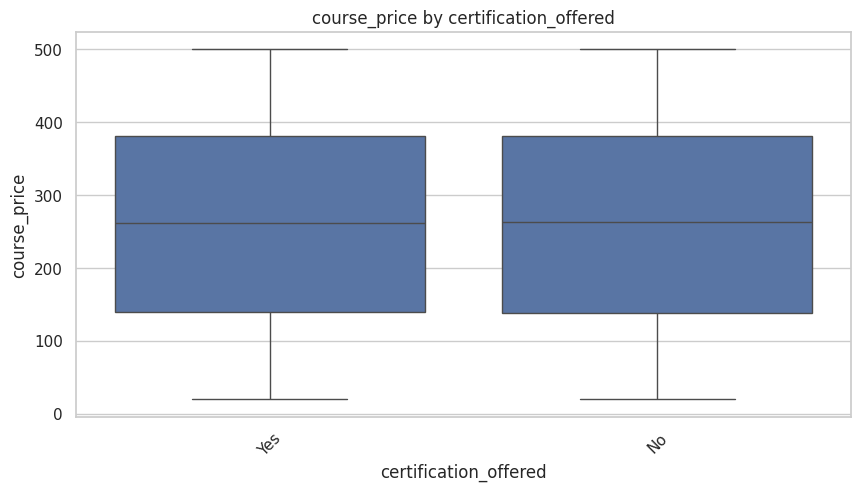

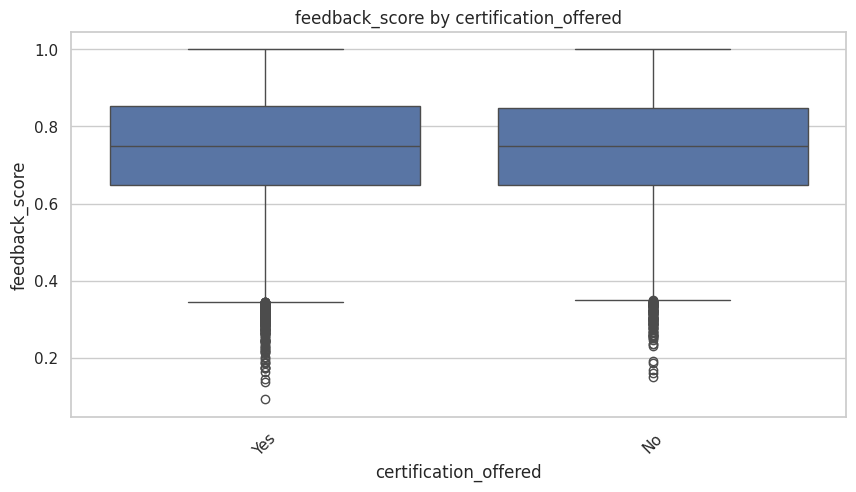

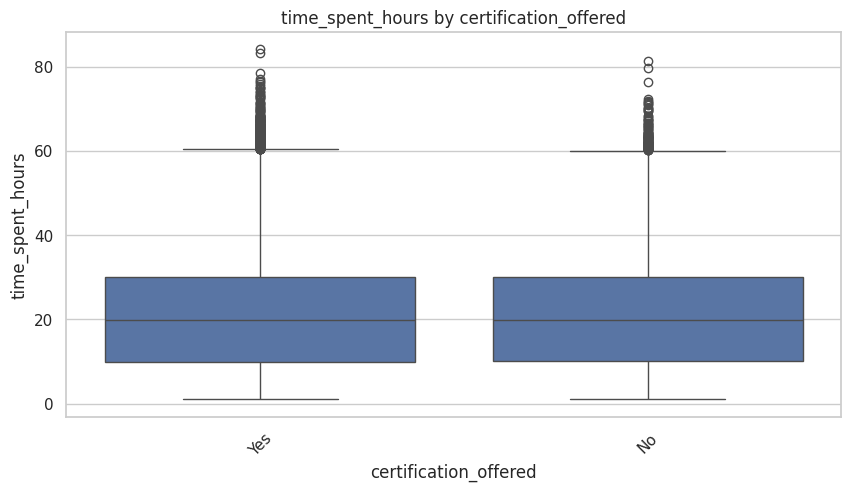

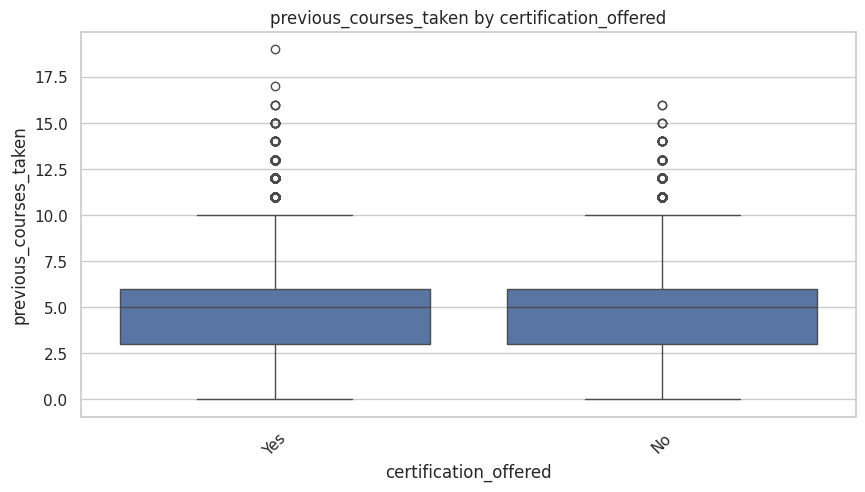

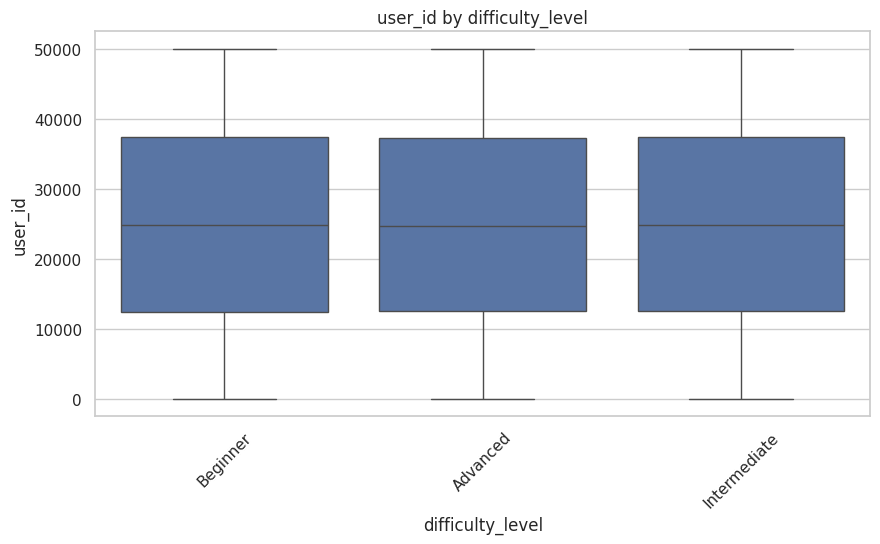

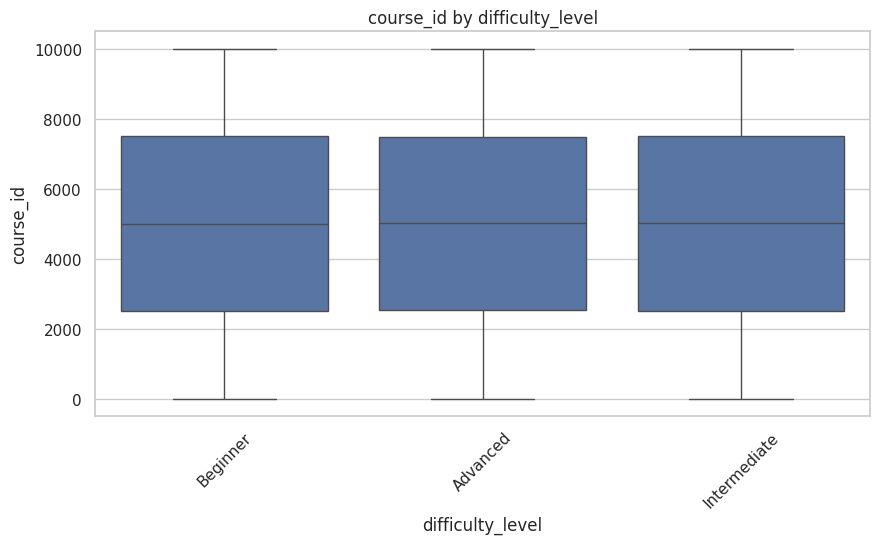

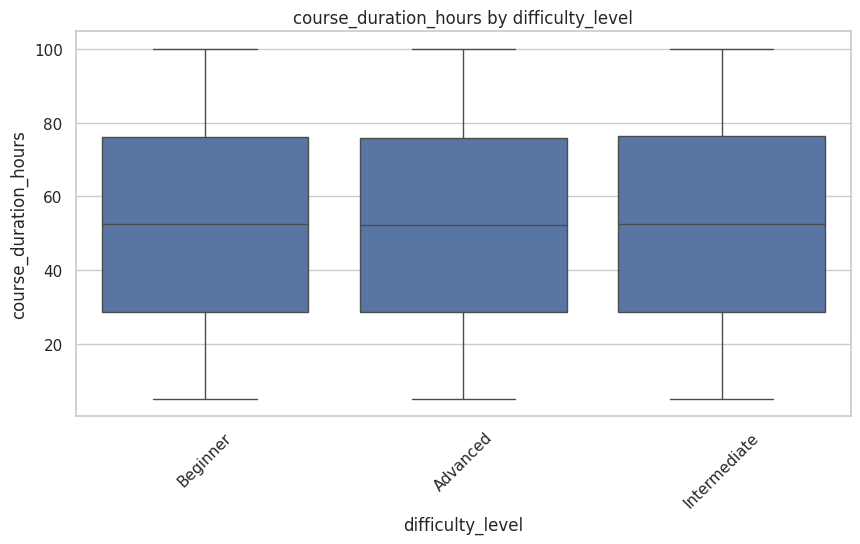

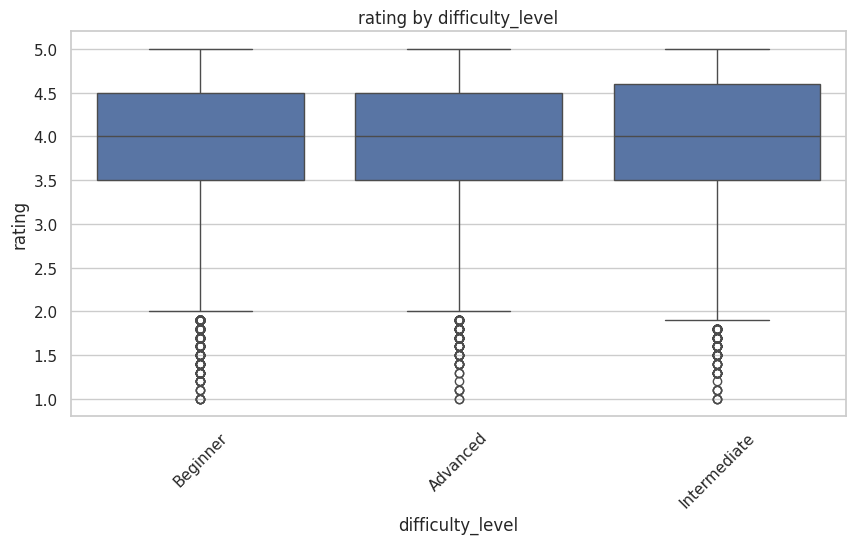

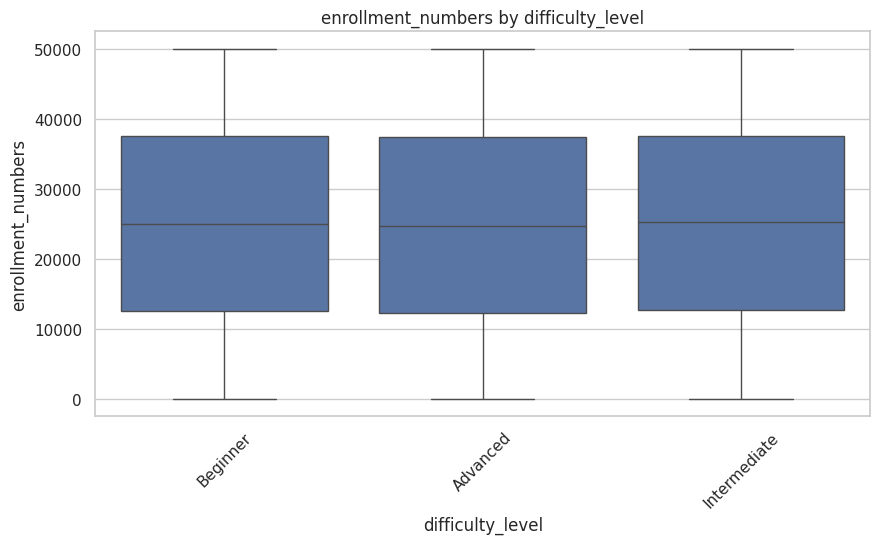

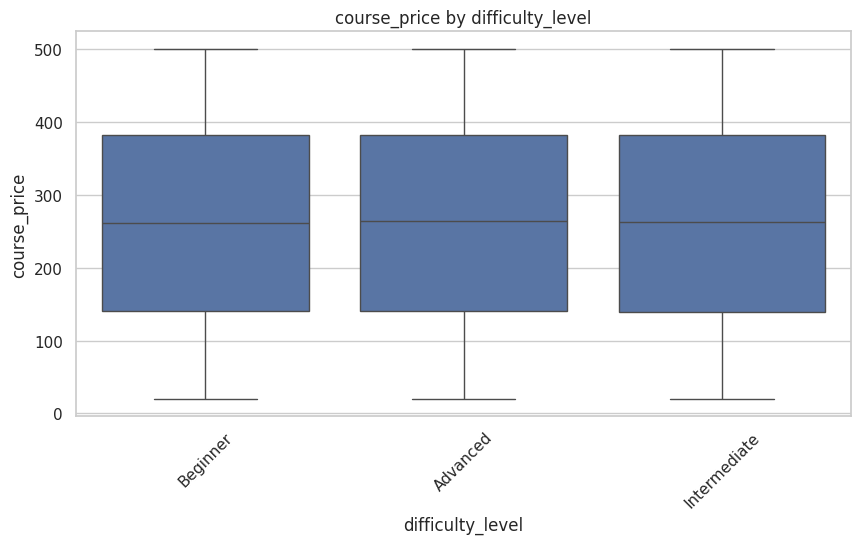

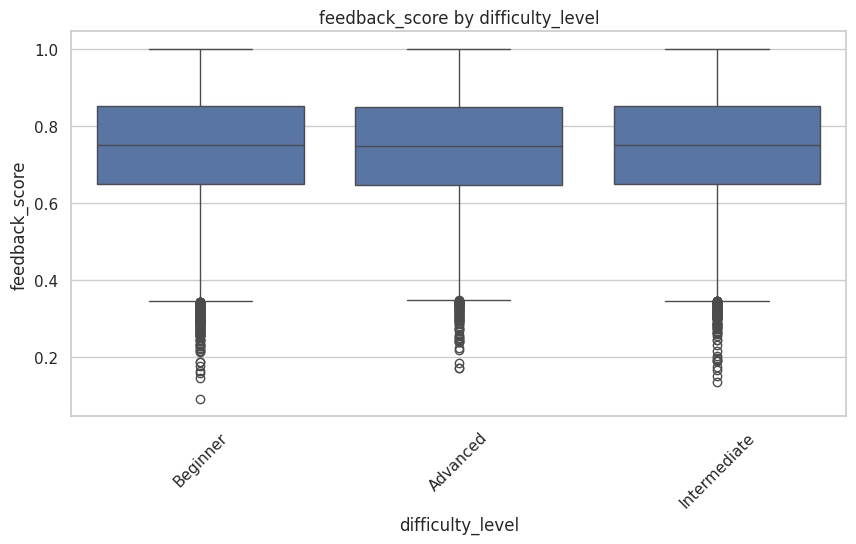

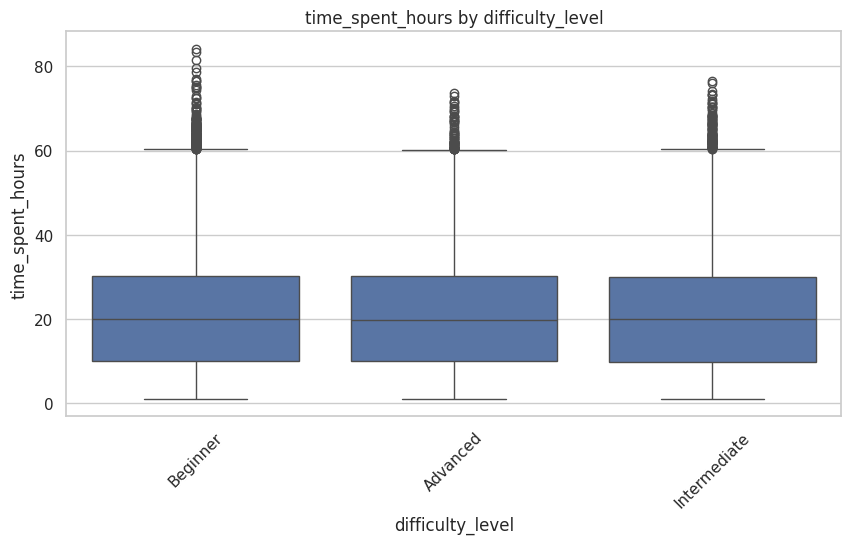

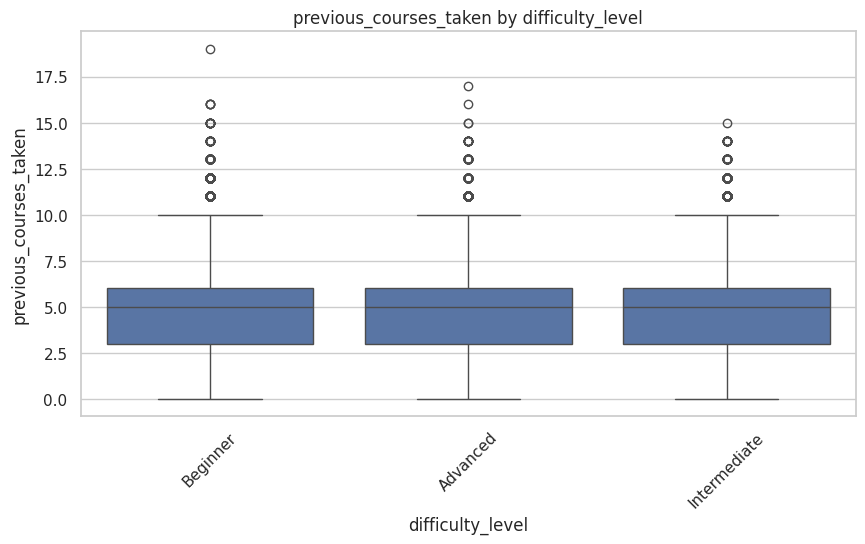

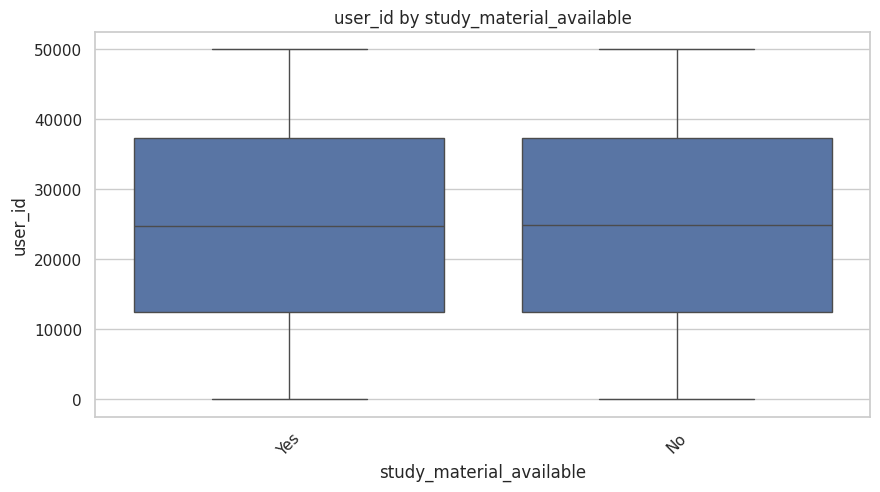

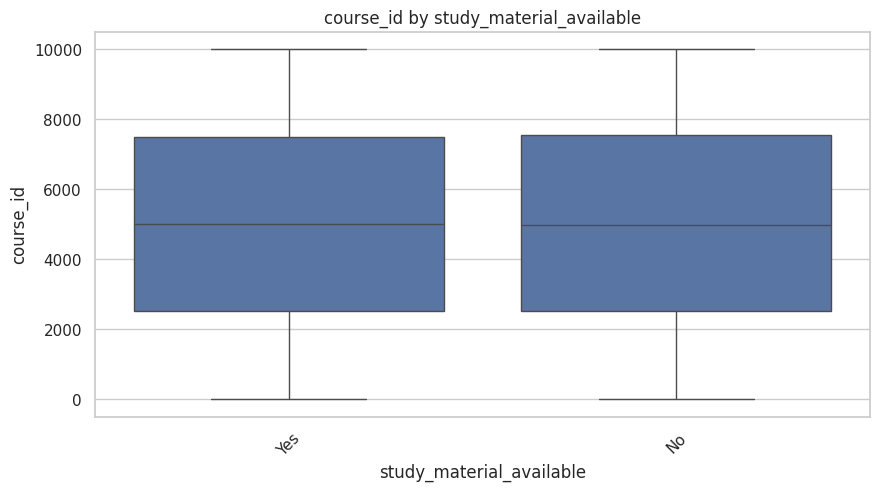

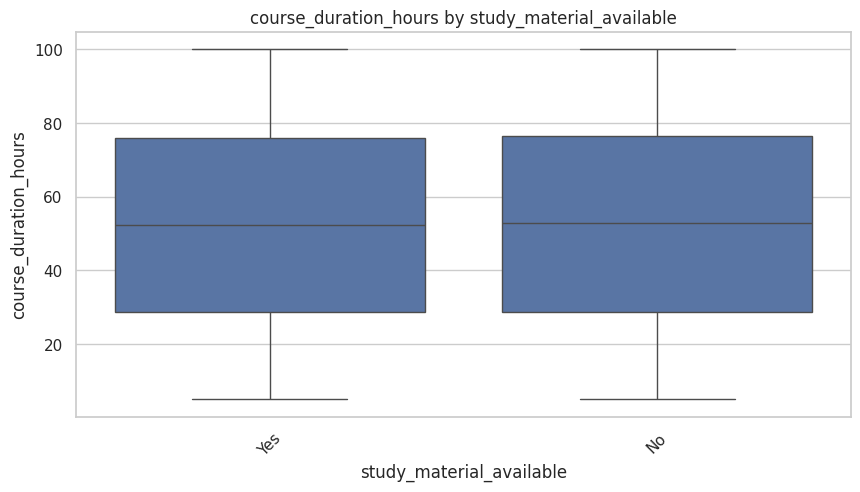

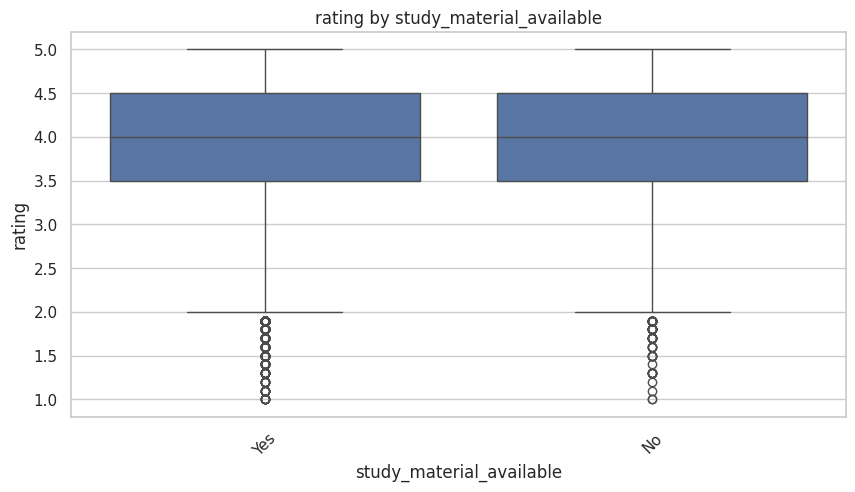

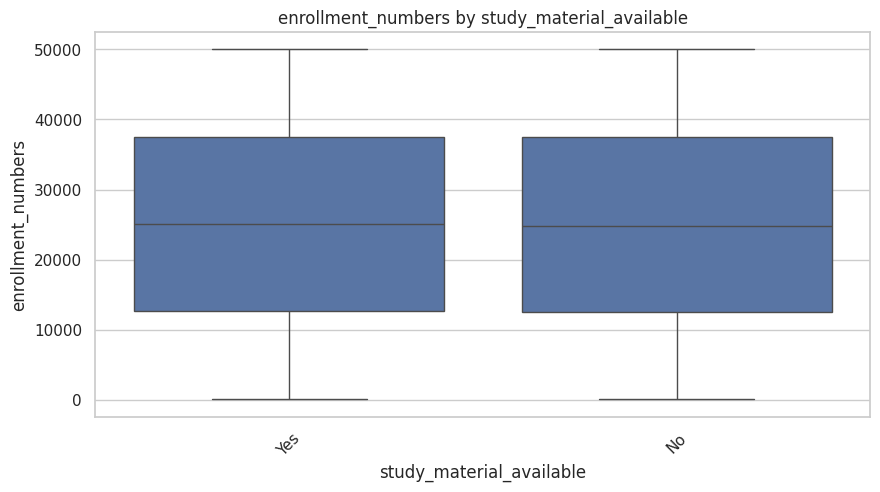

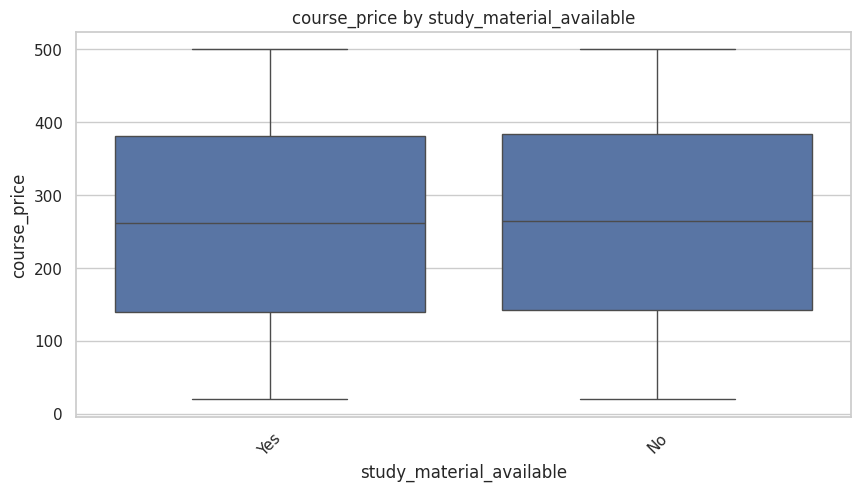

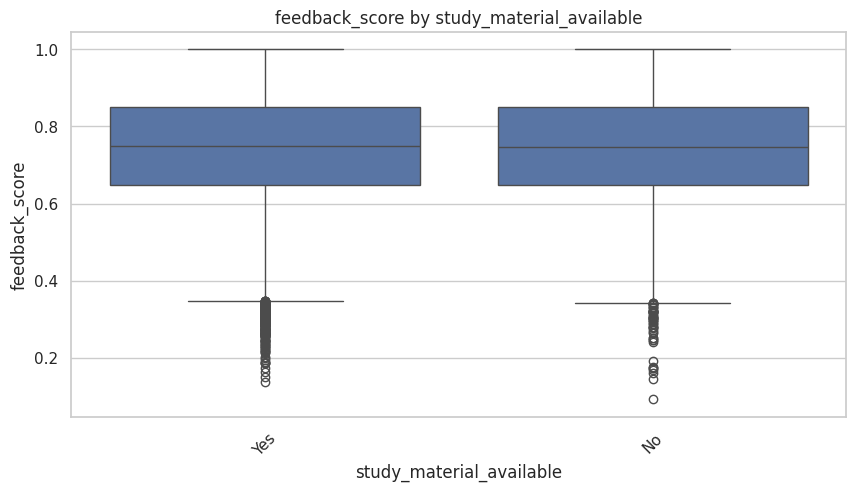

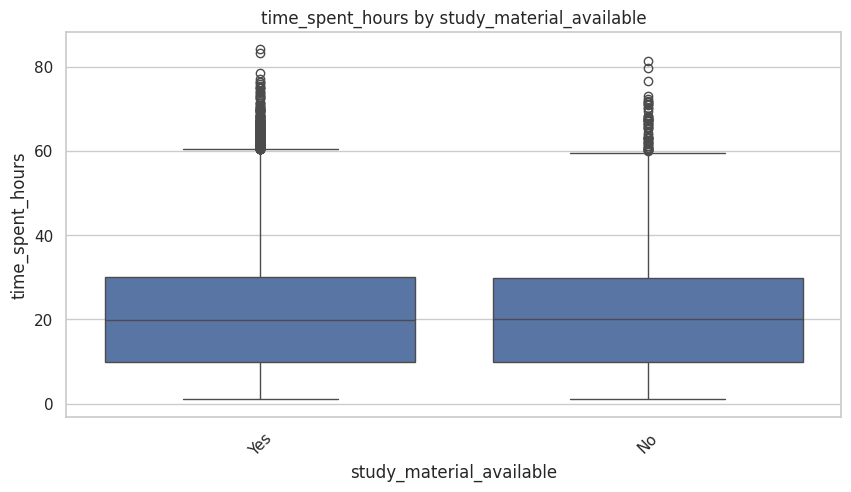

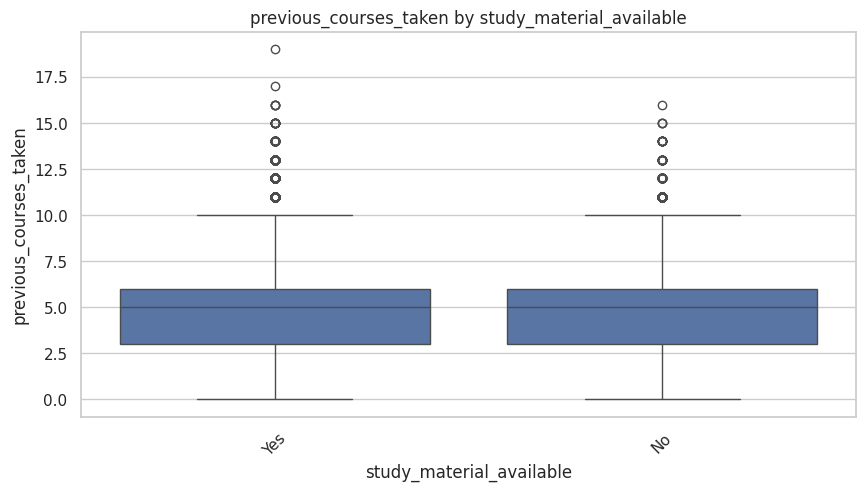

In [ ]:
# Step 13: Categorical vs Numeric Boxplots
for cat in categorical_cols:
    for num in numeric_cols:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=cat, y=num, data=df)
        plt.title(f'{num} by {cat}')
        plt.xticks(rotation=45)
        plt.show()


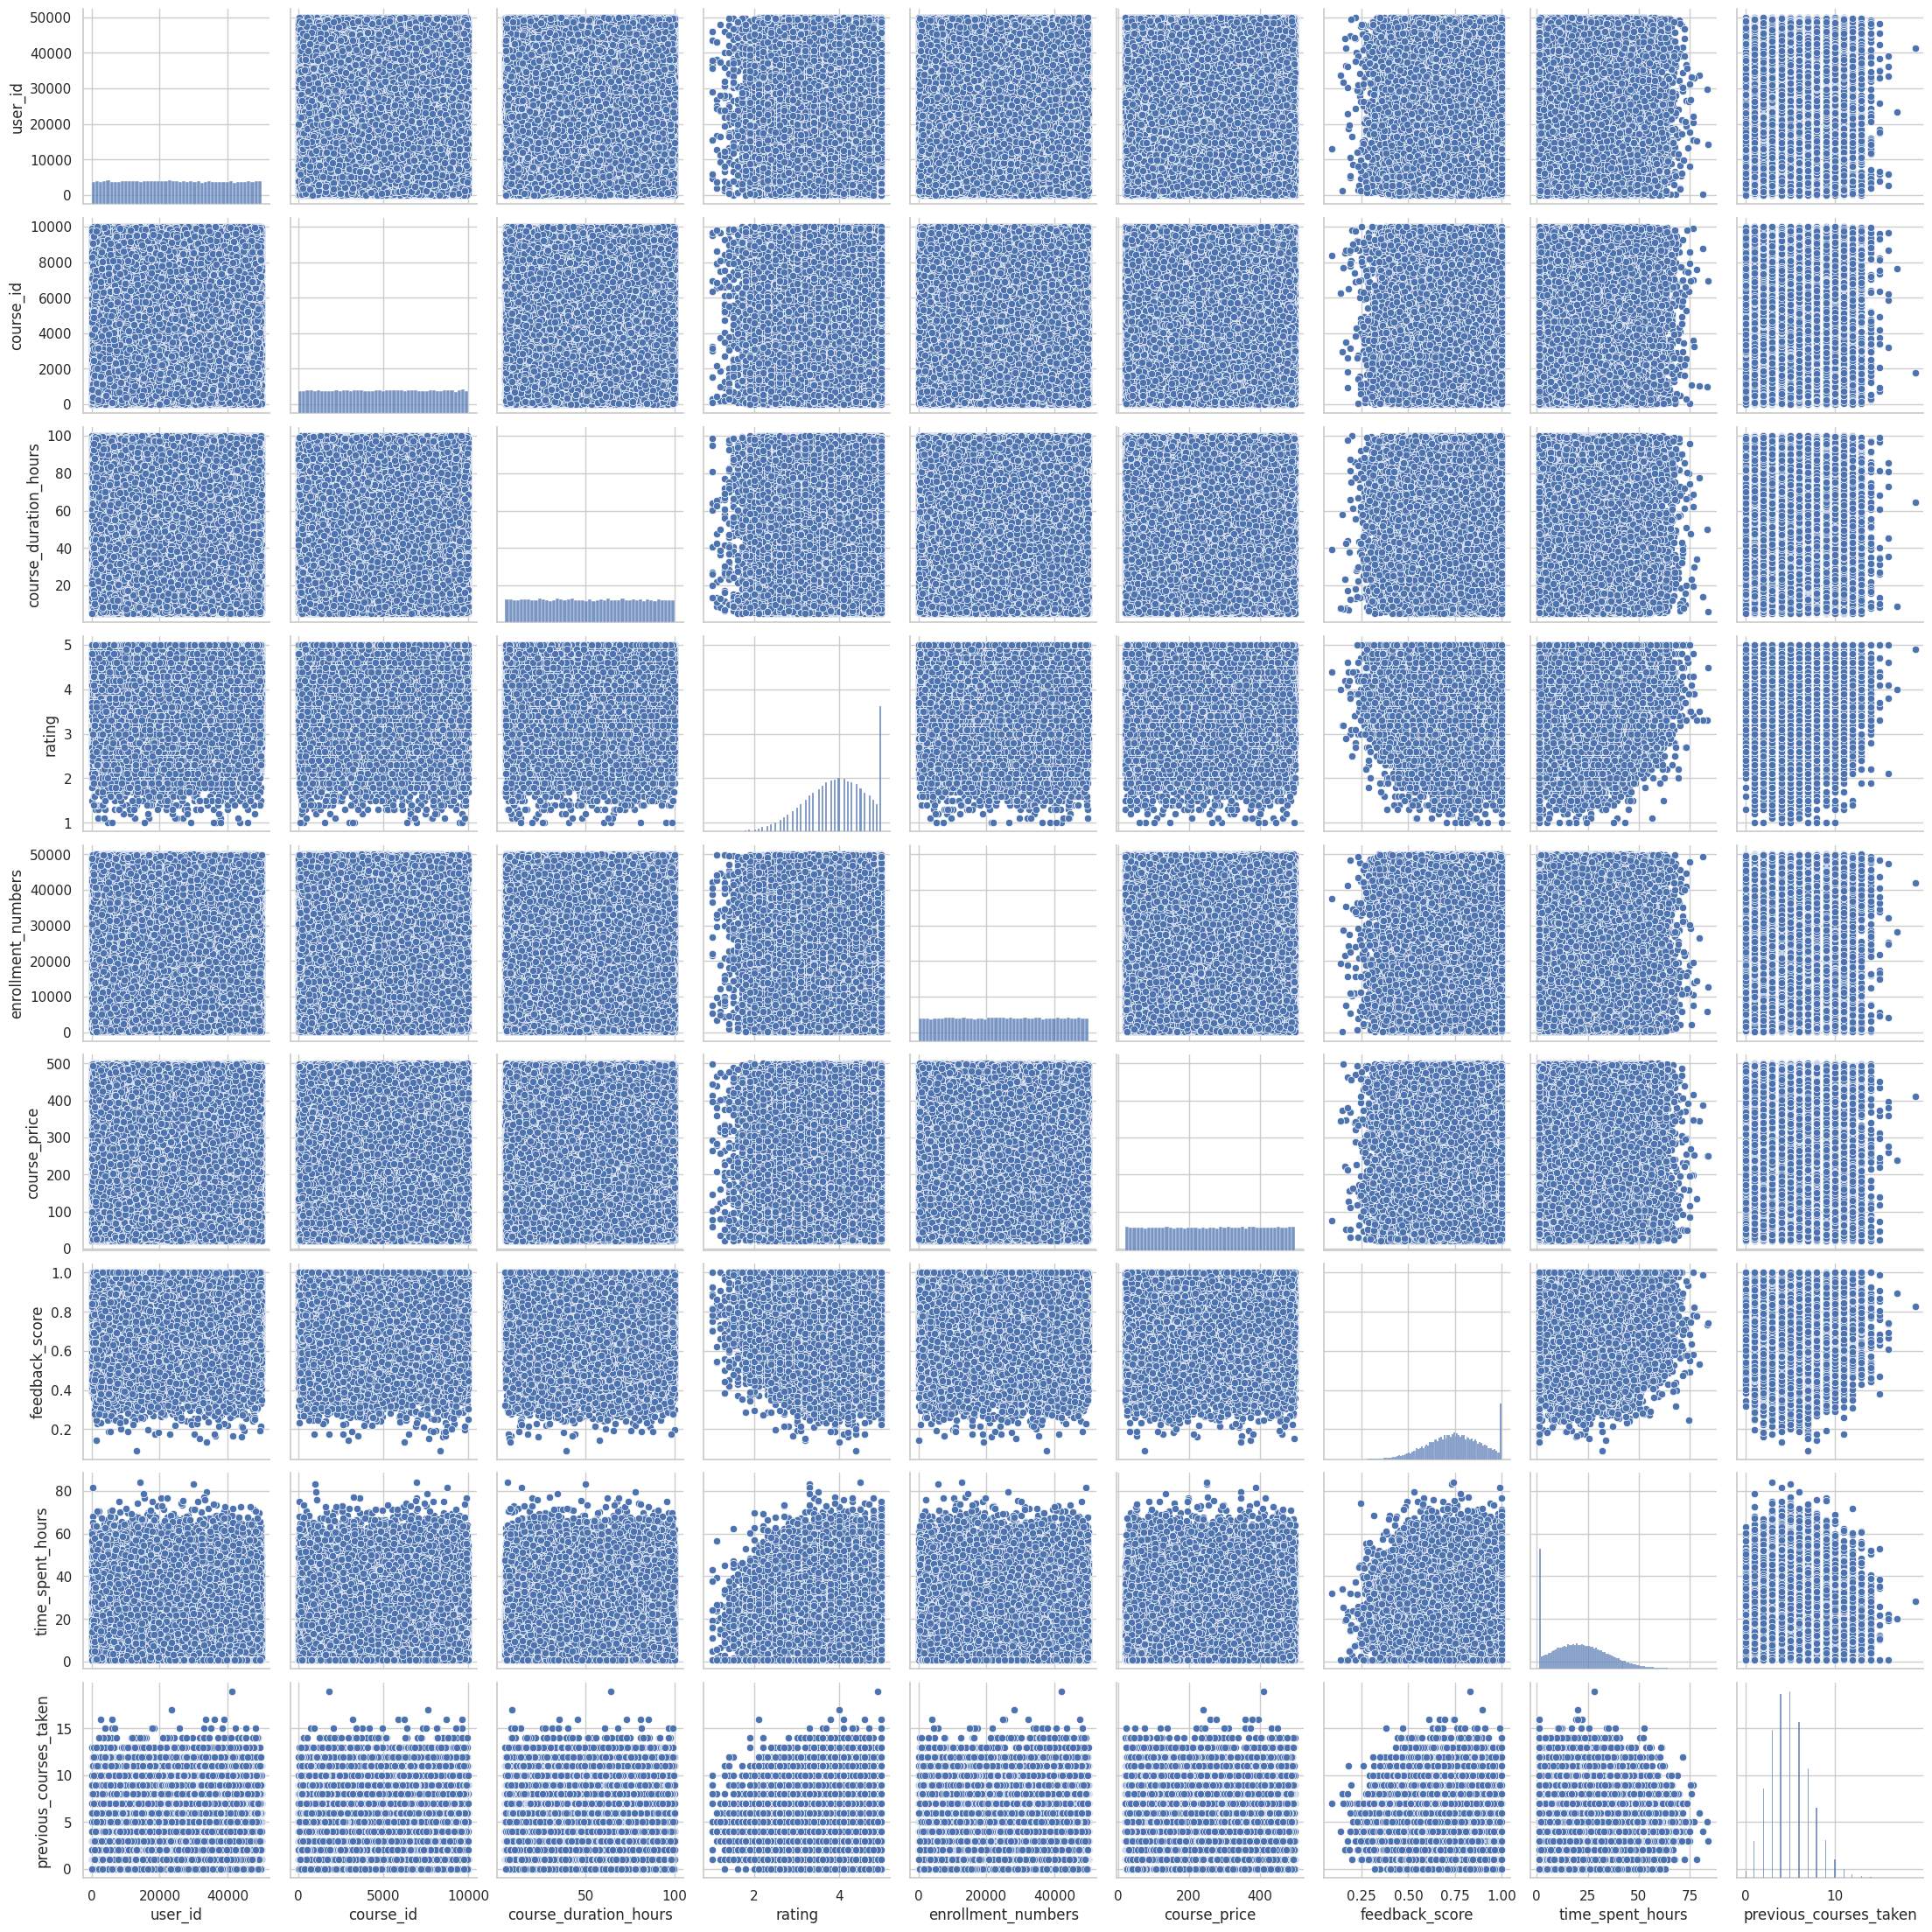

In [ ]:
# Pair plots
sns.pairplot(df)
plt.show()

In [ ]:
# Show missing values count for each column
df.isnull().sum()


,0
user_id,0
course_id,0
course_name,0
instructor,0
course_duration_hours,0
certification_offered,0
difficulty_level,0
rating,0
enrollment_numbers,0
course_price,0


# MODEL Building

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors

# ----------------- Load Dataset -----------------------
# Load the real dataset
df = pd.read_excel("/content/online_course_recommendation_v2.xlsx")

# Clean column names for consistency
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Create a description field for content-based filtering
df['description'] = (
    'Course: ' + df['course_name'] +
    '. Instructor: ' + df['instructor'] +
    '. Level: ' + df['difficulty_level'] +
    '. Duration: ' + df['course_duration_hours'].astype(str) + ' hours.'
)

# ----------------- 1. Popularity-Based ------------------
def get_top_courses_by_rating(df, n=5):
    return df.sort_values(by='rating', ascending=False)\
             .head(n)[['course_name', 'rating']]\
             .reset_index(drop=True)

def get_top_courses_by_enrollments(df, n=5):
    return df.sort_values(by='enrollment_numbers', ascending=False)\
             .head(n)[['course_name', 'enrollment_numbers']]\
             .reset_index(drop=True)

# ----------------- 2. Content-Based (Memory Efficient) ---------------------
def build_content_model_sparse(df, max_features=3000):
    tfidf = TfidfVectorizer(stop_words='english', max_features=max_features)
    tfidf_matrix = tfidf.fit_transform(df['description'])
    nn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
    nn.fit(tfidf_matrix)
    return nn, tfidf, tfidf_matrix

def recommend_similar_courses_sparse(title, df, nn, tfidf, tfidf_matrix):
    if title not in df['course_name'].values:
        return f"Course '{title}' not found in data."
    idx = df[df['course_name'] == title].index[0]
    _, indices = nn.kneighbors(tfidf_matrix[idx])
    indices = indices.flatten()[1:]  # Skip the first (same course)
    return df.iloc[indices][['course_name', 'description']].reset_index(drop=True)

# ----------------- 3. Collaborative Filtering -----------
def train_collaborative_model(df):
    df_copy = df[['user_id', 'course_id', 'rating']].dropna().copy()
    user_enc = LabelEncoder()
    course_enc = LabelEncoder()
    df_copy['user'] = user_enc.fit_transform(df_copy['user_id'])
    df_copy['course'] = course_enc.fit_transform(df_copy['course_id'])

    X = df_copy[['user', 'course']]
    y = df_copy['rating']

    model = Ridge()
    model.fit(X, y)

    return model, user_enc, course_enc

def predict_course_rating(model, user_enc, course_enc, user_id, course_id):
    try:
        user_idx = user_enc.transform([user_id])[0]
        course_idx = course_enc.transform([course_id])[0]
        return model.predict([[user_idx, course_idx]])[0]
    except:
        return "User or course not found in training data."

# ----------------- Example Usage -----------------------

# 1. Popularity-Based
print("📊 Top Rated Courses:\n", get_top_courses_by_rating(df))
print("\n👥 Top Enrolled Courses:\n", get_top_courses_by_enrollments(df))

# 2. Content-Based (Sparse Nearest Neighbors)
nn, tfidf, tfidf_matrix = build_content_model_sparse(df, max_features=3000)
example_title = df['course_name'].iloc[0]
print(f"\n📚 Courses similar to '{example_title}':\n",
      recommend_similar_courses_sparse(example_title, df, nn, tfidf, tfidf_matrix))

# 3. Collaborative Filtering
model, user_enc, course_enc = train_collaborative_model(df)
example_user = df['user_id'].iloc[0]
example_course = df['course_id'].iloc[0]
print(f"\n⭐ Predicted rating for user '{example_user}' on course '{example_course}':",
      predict_course_rating(model, user_enc, course_enc, example_user, example_course))


📊 Top Rated Courses:
                             course_name  rating
0                  Python for Beginners     5.0
1                  Python for Beginners     5.0
2       Project Management Fundamentals     5.0
3       Data Visualization with Tableau     5.0
4  Personal Finance and Wealth Building     5.0

👥 Top Enrolled Courses:
                             course_name  enrollment_numbers
0  Personal Finance and Wealth Building               49999
1     Fundamentals of Digital Marketing               49999
2     Mobile App Development with Swift               49999
3        Fitness and Nutrition Coaching               49999
4  Personal Finance and Wealth Building               49997

📚 Courses similar to 'Python for Beginners':
             course_name                                        description
0  Python for Beginners  Course: Python for Beginners. Instructor: Emma...
1  Python for Beginners  Course: Python for Beginners. Instructor: Emma...
2  Python for Beginners  Course:

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


Supervised Machine Learning - Classification task using the Random Forest Classifier.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading dataset
file_path = "/content/online_course_recommendation_v2.xlsx"
df = pd.read_excel("/content/online_course_recommendation_v2.xlsx")

# Preprocessing function
def preprocess_data(df):
    # Drop non-essential columns
    df.drop(columns=['user_id', 'course_id', 'course_name', 'instructor'], inplace=True)

    # Binary encoding for Yes/No columns
    df['certification_offered'] = df['certification_offered'].map({'Yes': 1, 'No': 0})
    df['study_material_available'] = df['study_material_available'].map({'Yes': 1, 'No': 0})

    # Ordinal encoding for difficulty level
    difficulty_map = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
    df['difficulty_level'] = df['difficulty_level'].map(difficulty_map)

    # Drop missing values if any remain
    df.dropna(inplace=True)

    return df

# Preprocess data
df = preprocess_data(df)

# Target: High rating (1 if rating >= 4, else 0)
df['high_rating'] = (df['rating'] >= 4.0).astype(int)

# Define features and label
X = df.drop(columns=['rating', 'high_rating'])
y = df['high_rating']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Model Accuracy: 50.31%

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.40      0.43      9498
           1       0.52      0.60      0.56     10502

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000

Confusion Matrix:
[[3805 5693]
 [4245 6257]]


CONFUSION MATRIX HEATMAP

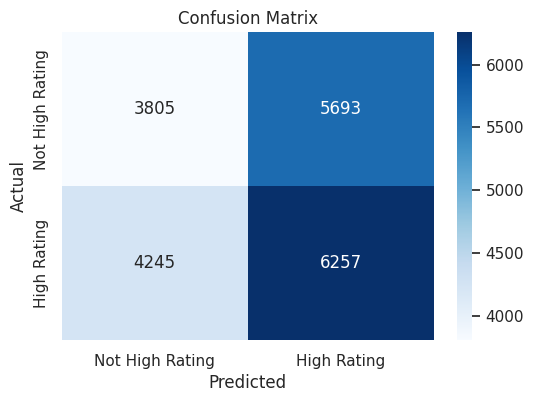

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not High Rating', 'High Rating'], yticklabels=['Not High Rating', 'High Rating'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()